In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors



In [ ]:

# ------------------------------------------------------------------
# Configuration: adjust these names to match your dataframe
# ------------------------------------------------------------------

MACRO_COL = "macro_genre"
SUBGENRE_COL = "genre"       # change to "subgenre" if needed

FEATURES = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

MACRO_GENRES = [
    "Electronic",
    "Rock",
    "Pop",
    "Latin",
    "Hip-Hop/R&B"
]


# ------------------------------------------------------------------
# Keep only tracks with a genuine granular genre annotation
# ------------------------------------------------------------------

df_granular = df.loc[
    df[SUBGENRE_COL].notna()
    & df[MACRO_COL].notna()
    & (df[SUBGENRE_COL].astype(str).str.strip() != "")
    & (
        df[SUBGENRE_COL].astype(str).str.lower().str.strip()
        != df[MACRO_COL].astype(str).str.lower().str.strip()
    )
].copy()

# Remove rows with missing audio features
df_granular = df_granular.dropna(subset=FEATURES).reset_index(drop=True)

# Standardize once on the complete granular subset.
# This preserves a common feature scale across macro-genres.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_granular[FEATURES])

# Store standardized vectors in a separate dataframe
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES,
    index=df_granular.index
)

print(f"Tracks with granular annotations: {len(df_granular):,}")
print("\nTracks by macro-genre:")
display(
    df_granular[MACRO_COL]
    .value_counts()
    .loc[lambda x: x.index.isin(MACRO_GENRES)]
    .to_frame("tracks")
)

In [ ]:
def mean_group_dispersion(X, labels, min_group_size=2):
    """
    For each group, compute the mean Euclidean distance of its tracks
    from the group centroid in standardized feature space.

    Returns the unweighted mean across valid groups.
    """
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)

    group_scores = []

    for label in pd.unique(labels):
        mask = labels == label
        X_group = X[mask]

        if len(X_group) < min_group_size:
            continue

        centroid = X_group.mean(axis=0)
        distances = np.linalg.norm(X_group - centroid, axis=1)
        group_scores.append(distances.mean())

    return float(np.mean(group_scores)) if group_scores else np.nan


def local_community_consistency(G, partition):
    """
    Average proportion of each node's neighbours belonging to the
    same Louvain community as the node itself.
    """
    scores = []

    for node in G.nodes:
        neighbours = list(G.neighbors(node))

        if not neighbours:
            continue

        same_community = sum(
            partition[neighbour] == partition[node]
            for neighbour in neighbours
        )

        scores.append(same_community / len(neighbours))

    return float(np.mean(scores)) if scores else np.nan


def evaluate_macro_network(
    df_macro,
    X_macro,
    subgenre_col,
    k=5,
    resolution=1.0,
    random_state=42
):
    """
    Build a symmetrized cosine k-NN graph and compute:
      - subgenre assortativity
      - Louvain modularity
      - local community consistency
      - subgenre acoustic dispersion
      - community acoustic dispersion
    """
    df_macro = df_macro.reset_index(drop=True)
    X_macro = np.asarray(X_macro, dtype=float)

    n_tracks = len(df_macro)

    if n_tracks < 3:
        raise ValueError("At least three tracks are required.")

    # +1 because the nearest neighbour returned is the observation itself
    k_effective = min(k, n_tracks - 1)

    neighbours = NearestNeighbors(
        n_neighbors=k_effective + 1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    neighbours.fit(X_macro)
    distances, indices = neighbours.kneighbors(X_macro)

    # --------------------------------------------------------------
    # Build an undirected graph from the directed k-NN relationships
    # --------------------------------------------------------------

    G = nx.Graph()
    G.add_nodes_from(range(n_tracks))

    for source in range(n_tracks):
        for distance, target in zip(
            distances[source, 1:],
            indices[source, 1:]
        ):
            similarity = max(0.0, 1.0 - float(distance))

            # If an edge is selected in both directions, retain the
            # highest observed similarity.
            if G.has_edge(source, target):
                G[source][target]["weight"] = max(
                    G[source][target]["weight"],
                    similarity
                )
            else:
                G.add_edge(
                    source,
                    int(target),
                    weight=similarity,
                    distance=float(distance)
                )

    # Add subgenre labels as node attributes
    subgenre_labels = df_macro[subgenre_col].astype(str).to_dict()
    nx.set_node_attributes(G, subgenre_labels, "subgenre")

    # --------------------------------------------------------------
    # Louvain community detection
    # --------------------------------------------------------------

    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=resolution,
        seed=random_state
    )

    partition = {
        node: community_id
        for community_id, community_nodes in enumerate(communities)
        for node in community_nodes
    }

    community_labels = np.array(
        [partition[node] for node in range(n_tracks)]
    )

    # --------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------

    assortativity = nx.attribute_assortativity_coefficient(
        G,
        "subgenre"
    )

    modularity = nx.community.modularity(
        G,
        communities,
        weight="weight",
        resolution=resolution
    )

    consistency = local_community_consistency(G, partition)

    subgenre_dispersion = mean_group_dispersion(
        X_macro,
        df_macro[subgenre_col].astype(str).to_numpy()
    )

    community_dispersion = mean_group_dispersion(
        X_macro,
        community_labels
    )

    result = {
        "Tracks": n_tracks,
        "Edges": G.number_of_edges(),
        "Communities": len(communities),
        "Subgenre assortativity": assortativity,
        "Modularity": modularity,
        "Local consistency": consistency,
        "Subgenre dispersion": subgenre_dispersion,
        "Community dispersion": community_dispersion
    }

    return result, G, partition



In [ ]:
# ------------------------------------------------------------------
# Run the same pipeline using different hardcoded filters
# ------------------------------------------------------------------

SUBSET_FILTERS = {
    "Electronic": (
        df_granular[MACRO_COL].eq("Electronic")
        & df_granular[SUBGENRE_COL].isin([
            "breakbeat",
            "chicago-house",
            "club",
            "dance",
            "deep-house",
            "detroit-techno",
            "disco",
            "drum-and-bass",
            "dubstep",
            "edm",
            "electro",
            "garage",
            "hardstyle",
            "house",
            "idm",
            "industrial",
            "minimal-techno",
            "progressive-house",
            "techno",
            "trance"
        ])
    ),

    "Rock": (
        df_granular[MACRO_COL].eq("Rock")
        & df_granular[SUBGENRE_COL].isin([
            # Insert the Rock subgenres to retain
        ])
    ),

    "Pop": (
        df_granular[MACRO_COL].eq("Pop")
        & df_granular[SUBGENRE_COL].isin([
            "cantopop",
            "j-pop",
            "k-pop",
            "mandopop",
            "power-pop",
            "synth-pop"
        ])
    ),

    "Latin": (
        df_granular[MACRO_COL].eq("Latin")
        & df_granular[SUBGENRE_COL].isin([
            "brazil",
            "forro",
            "mpb",
            "pagode",
            "reggaeton",
            "salsa",
            "samba",
            "sertanejo",
            "tango"
        ])
    ),

    "Hip-Hop/R&B": (
        df_granular[MACRO_COL].eq("Hip-Hop/R&B")
        & df_granular[SUBGENRE_COL].isin([
            # Insert the Hip-Hop/R&B subgenres to retain
        ])
    )
}


results = []
network_objects = {}

for macro, mask in SUBSET_FILTERS.items():

    df_macro = df_granular.loc[mask].copy()

    # Preserve alignment with the standardized feature dataframe
    X_macro = X_scaled_df.loc[df_macro.index].to_numpy()

    if len(df_macro) < 3:
        print(f"Skipping {macro}: insufficient observations.")
        continue

    metrics, G_macro, partition_macro = evaluate_macro_network(
        df_macro=df_macro,
        X_macro=X_macro,
        subgenre_col=SUBGENRE_COL,
        k=5,
        resolution=1.0,
        random_state=42
    )

    metrics[MACRO_COL] = macro
    results.append(metrics)

    network_objects[macro] = {
        "graph": G_macro,
        "partition": partition_macro,
        "data": df_macro.reset_index(drop=True),
        "X": X_macro
    }


results_df = (
    pd.DataFrame(results)
    .set_index(MACRO_COL)
    .reindex(SUBSET_FILTERS.keys())
)

metric_columns = [
    "Subgenre assortativity",
    "Modularity",
    "Local consistency",
    "Subgenre dispersion",
    "Community dispersion"
]

display(
    results_df[
        ["Tracks", "Edges", "Communities"] + metric_columns
    ].round(3)
)

In [ ]:

# ------------------------------------------------------------------
# Run the same pipeline for every selected macro-genre
# ------------------------------------------------------------------

results = []
network_objects = {}

for macro in MACRO_GENRES:

    mask = df_granular[MACRO_COL].eq(macro)

    df_macro = df_granular.loc[mask].copy()
    X_macro = X_scaled_df.loc[mask].to_numpy()

    if len(df_macro) < 3:
        print(f"Skipping {macro}: insufficient observations.")
        continue

    metrics, G_macro, partition_macro = evaluate_macro_network(
        df_macro=df_macro,
        X_macro=X_macro,
        subgenre_col=SUBGENRE_COL,
        k=5,                  # use the same final k as your main analysis
        resolution=1.0,
        random_state=42
    )

    metrics[MACRO_COL] = macro
    results.append(metrics)

    # Retain graphs and partitions for later inspection if needed
    network_objects[macro] = {
        "graph": G_macro,
        "partition": partition_macro,
        "data": df_macro.reset_index(drop=True),
        "X": X_macro
    }

results_df = (
    pd.DataFrame(results)
    .set_index(MACRO_COL)
    .loc[MACRO_GENRES]
)

metric_columns = [
    "Subgenre assortativity",
    "Modularity",
    "Local consistency",
    "Subgenre dispersion",
    "Community dispersion"
]

display(
    results_df[
        ["Tracks", "Edges", "Communities"] + metric_columns
    ].round(3)
)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
spotify = pd.read_csv("spotify_merged_clean.csv")

In [3]:
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

spotify.drop(columns=['key', 'mode'], inplace=True)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering = spotify[continuous_features].copy()

spotify[continuous_features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090
...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234


In [4]:
GENRE_MAPPING = {
    # Rock
    "rock": "Rock",
    "alt-rock": "Rock",
    "album rock": "Rock",
    "classic rock": "Rock",
    "hard-rock": "Rock",
    "hard rock": "Rock",
    "psych-rock": "Rock",
    "rock-n-roll": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    "j-rock": "Rock",
    "permanent wave": "Rock",

    # Punk / Alternative
    "alternative": "Alternative",
    "indie": "Alternative",
    "indie-pop": "Alternative",
    "indie poptimism": "Alternative",
    "emo": "Alternative",
    "goth": "Alternative",
    "punk": "Alternative",
    "punk-rock": "Alternative",

    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "death-metal": "Metal",
    "black-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "groove": "Metal",
    "hardcore": "Metal",

    # Pop
    "pop": "Pop",
    "dance pop": "Pop",
    "electropop": "Pop",
    "post-teen pop": "Pop",
    "power-pop": "Pop",
    "synth-pop": "Pop",
    "j-pop": "Pop",
    "k-pop": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "latin pop": "Pop",
    "hip pop": "Pop",

    # Hip Hop / R&B
    "rap": "Hip-Hop/R&B",
    "hip-hop": "Hip-Hop/R&B",
    "hip hop": "Hip-Hop/R&B",
    "r&b": "Hip-Hop/R&B",
    "r-n-b": "Hip-Hop/R&B",
    "neo soul": "Hip-Hop/R&B",
    "new jack swing": "Hip-Hop/R&B",
    "urban contemporary": "Hip-Hop/R&B",
    "southern hip hop": "Hip-Hop/R&B",
    "latin hip hop": "Hip-Hop/R&B",
    "gangster rap": "Hip-Hop/R&B",
    "trap": "Hip-Hop/R&B",
    "soul": "Hip-Hop/R&B",

    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "electro house": "Electronic",
    "progressive electro house": "Electronic",
    "techno": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "idm": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "hardstyle": "Electronic",
    "big room": "Electronic",
    "pop edm": "Electronic",
    "disco": "Electronic",
    "industrial": "Electronic",

    # Ambient / Chill
    "ambient": "Ambient/Chill",
    "chill": "Ambient/Chill",
    "new-age": "Ambient/Chill",
    "sleep": "Ambient/Chill",
    "study": "Ambient/Chill",
    "trip-hop": "Ambient/Chill",
    "tropical": "Ambient/Chill",

    # Folk / Country
    "folk": "Folk/Country",
    "acoustic": "Folk/Country",
    "country": "Folk/Country",
    "bluegrass": "Folk/Country",
    "honky-tonk": "Folk/Country",
    "singer-songwriter": "Folk/Country",

    # Jazz / Blues
    "jazz": "Jazz/Blues",
    "blues": "Jazz/Blues",
    "gospel": "Jazz/Blues",
    "funk": "Jazz/Blues",

    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    "ska": "Reggae",

    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "reggaeton": "Latin",
    "salsa": "Latin",
    "tango": "Latin",
    "samba": "Latin",
    "pagode": "Latin",
    "mpb": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "brazil": "Latin",

    # World
    "afrobeat": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "world-music": "World",

    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",

    # Soundtracks
    "anime": "Soundtrack",
    "disney": "Soundtrack",
    "show-tunes": "Soundtrack",
    "pop-film": "Soundtrack",

    # Kids
    "children": "Kids",
    "kids": "Kids",

    # Spoken
    "comedy": "Spoken",

    # Mood
    "happy": "Mood",
    "sad": "Mood",
    "party": "Mood",
    "romance": "Mood",

    # Instrumental
    "guitar": "Instrumental",

    # Regional labels
    "british": "Regional",
    "french": "Regional",
    "german": "Regional",
    "spanish": "Regional",
    "swedish": "Regional",
    "j-idol": "Regional",
    "j-dance": "Regional",
}

In [5]:
super_genres = {genre: [] for genre in GENRE_MAPPING.values()}

for name, super_genre in GENRE_MAPPING.items():
    super_genres[super_genre].append(name)

for genre in super_genres:
    print(f"{genre:15} \tSub-genres: {super_genres[genre]}")

Rock            	Sub-genres: ['rock', 'alt-rock', 'album rock', 'classic rock', 'hard-rock', 'hard rock', 'psych-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'j-rock', 'permanent wave']
Alternative     	Sub-genres: ['alternative', 'indie', 'indie-pop', 'indie poptimism', 'emo', 'goth', 'punk', 'punk-rock']
Metal           	Sub-genres: ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore', 'groove', 'hardcore']
Pop             	Sub-genres: ['pop', 'dance pop', 'electropop', 'post-teen pop', 'power-pop', 'synth-pop', 'j-pop', 'k-pop', 'cantopop', 'mandopop', 'latin pop', 'hip pop']
Hip-Hop/R&B     	Sub-genres: ['rap', 'hip-hop', 'hip hop', 'r&b', 'r-n-b', 'neo soul', 'new jack swing', 'urban contemporary', 'southern hip hop', 'latin hip hop', 'gangster rap', 'trap', 'soul']
Electronic      	Sub-genres: ['edm', 'electronic', 'electro', 'house', 'deep-house', 'chicago-house', 'progressive-house', 'electro house', 'progressive electro house', 'techno', 'minimal-te

Now I would like to see with different number of cluster what we are able to achieve and analyze those clusters

In [6]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


## Dimensionality reduction through PCA

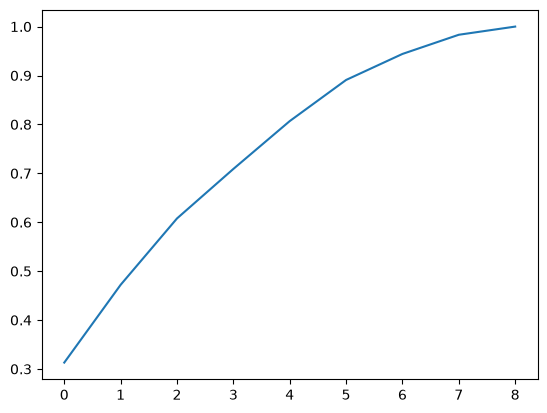

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_for_clustering)

plt.plot(np.cumsum(pca.explained_variance_ratio_))

### Network Exploration

Do the genre represent cleanly the music? The answer is no. If genres do not form distinct clusters, what is the intrinsic organization of the musical feature space? Let's try to explore its nature to understand how are organized. 

Each song becomes a node
Compute similarity
Correlation?Less common here because every song only has 11 attributes.
Usually cosine works better.

#### Build the graph

Now every song has similarities to every other song. If you have 100,000 songs you have 100000²
possible edges. Impossible.

So we sparsify the graph.
There are two common methods:

1. Method 1 — Threshold graph: similarity > 0.9. Problem: Different regions have different densities. Some songs may end up isolated.
2. k-nearest neighbours (recommended): For every song
find
k = 10
closest songs.
Then connect them.
Example

Song A

 ├── Song C 

 ├── Song D

 ├── Song X

 ├── Song K

 └── ...

Advantages
no isolated nodes
sparse graph
scalable
standard approach in manifold learning (UMAP, Isomap, spectral clustering all start from a kNN graph)
I would definitely choose this.

1. Do genres form homogeneous neighbourhoods? How pure are local neighbourhoods? You may discover that some genres have much sharper local identities than others.
2. Which genres overlap? Instead of clusters, count neighbour relationships.

This immediately tells you
Hip-Hop acoustically overlaps with Pop, while Metal is much more isolated.
You can even build a genre transition matrix from these neighbour counts.

3. Are there bridge songs? Betweenness centrality may identify exactly these songs. Interpretation
Bridge songs combine characteristics from multiple genres and may represent crossover styles.

4. Communities: Instead of forcing
k = 10
clusters,
run
Louvain
Leiden
on the graph.
Communities emerge naturally.
Unlike K-Means, these communities are based on connectivity rather than spherical geometry.


Which songs are central?

Degree

High degree

↓

very typical songs.

These songs resemble many others.

PageRank

↓

songs connected to other influential songs.

Maybe representative songs.

Betweenness

↓

songs linking otherwise separate musical communities.

These are your crossover tracks.



After building the graph, compute the assortativity by genre.

This is a network-science measure asking:

Do nodes tend to connect to other nodes with the same label?

In your context:

If assortativity is high, songs mostly connect to others from the same genre.
If it is low, genres are highly intermixed.
If some genres have high assortativity while others don't, you can discuss which genres have a stronger acoustic identity.

This metric ties your clustering results and your network analysis together. Clustering says there are no clean global partitions; assortativity tells you whether there is still meaningful local organization. That is a much more nuanced conclusion than simply saying "clustering didn't work."



Genre Similarity Graph ★★★★★

Instead of songs...
Nodes = genres.

For each genre compute the average feature vector.
Then compute cosine similarity

Rock -------- Alternative
Pop -------- Dance Pop
Hip Hop ----- Trap

Edge weight
cosine similarity

Now you can
- visualize the graph
- detect communities
- compute centrality

This tells you
Which genres are acoustically closest?

Correlation Graph between Features ★★★★☆
connect features.
|corr| > 0.6
Now compute

degree
PageRank
betweenness

Questions become

Which audio feature is most central?
Which features bridge different musical properties?
Which features form communities?

# The Feature Correlation Graph (The "DNA")

In [8]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


In [9]:
top_5 = vc.head(5).index.tolist()
print(top_5)

['Electronic', 'Latin', 'Hip-Hop/R&B', 'Pop', 'Rock']


In [10]:
def filter_by_macro_genre(df, genre: str):
    df_filtered = df[df['macro_genre'] == genre].copy()
    print(df_filtered.shape[0])

    df_filtered[continuous_features] = StandardScaler().fit_transform(df_filtered[continuous_features])

    df_filtered.drop(columns=['key', 'mode'], inplace=True, errors='ignore')
    print(df_filtered.shape[0])

    df_filtered = df_filtered[df_filtered['genre'].str.lower() != genre.lower()]
    print(f'Post filtering by genre "{genre}": {df_filtered.shape[0]} rows remaining.')

    df_filtered.reset_index(drop=True, inplace=True)
    print(f'Post resetting index for genre "{genre}": {df_filtered.shape[0]} rows remaining.')

    df_for_clustering = df_filtered[continuous_features].copy()
    print(df_for_clustering.shape[0])


    return df_filtered, df_for_clustering


In [11]:
electronic_spotify, electronic_for_clustering = filter_by_macro_genre(spotify, "Electronic")

19481
19481
Post filtering by genre "Electronic": 18673 rows remaining.
Post resetting index for genre "Electronic": 18673 rows remaining.
18673


In [12]:
import networkx as nx

# 1. Calculate the correlation matrix
corr_matrix = electronic_for_clustering.corr()

# 2. Convert to "long-form" to filter edges
# We stack it and reset index to get: Feature 1 | Feature 2 | Correlation
links = corr_matrix.stack().reset_index()
links.columns = ['var1', 'var2', 'value']

# 3. Filter out self-correlations (e.g., energy to energy) 
# and keep only one side of the matrix (to avoid double edges)
links_filtered = links.loc[(links['value'] != 1) & (links['var1'] < links['var2'])]

In [13]:
# Create the graph object
G_features = nx.Graph()

# Set a threshold for edges (adjust this to make the graph cleaner or busier)
threshold = 0.25

for index, row in links_filtered.iterrows():
    if abs(row['value']) > threshold:
        # Add edge with 'weight' and 'color' (red for negative, green/blue for positive)
        color = 'tomato' if row['value'] < 0 else 'skyblue'
        G_features.add_edge(row['var1'], row['var2'], weight=abs(row['value']), color=color, raw_corr=row['value'])

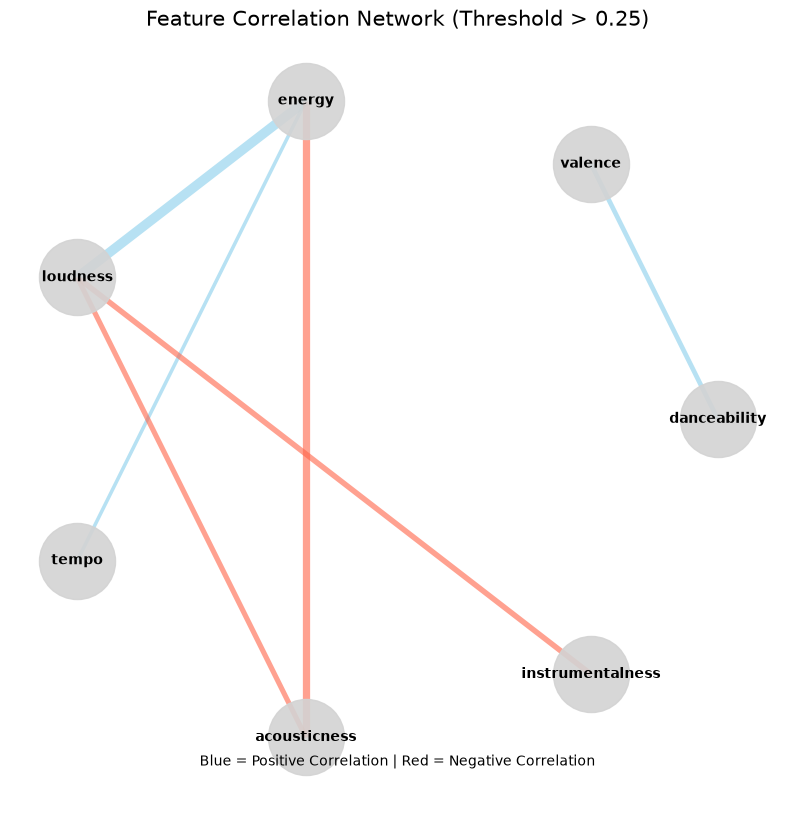

In [14]:
plt.figure(figsize=(10, 10))

# Positions for circular layout
pos = nx.circular_layout(G_features)

# Extract edge properties
edges = G_features.edges(data=True)
colors = [d['color'] for u, v, d in edges]
weights = [d['weight'] * 10 for u, v, d in edges] # Multiply by 10 for visible thickness

# Draw nodes
nx.draw_networkx_nodes(G_features, pos, node_size=3000, node_color='lightgrey', alpha=0.9)

# Draw labels
nx.draw_networkx_labels(G_features, pos, font_size=10, font_family='sans-serif', font_weight='bold')

# Draw edges
nx.draw_networkx_edges(G_features, pos, edgelist=edges, width=weights, edge_color=colors, alpha=0.6)

plt.title(f"Feature Correlation Network (Threshold > {threshold})", fontsize=15)
plt.annotate('Blue = Positive Correlation | Red = Negative Correlation', xy=(0.5, 0.05), xycoords='axes fraction', ha='center')
plt.axis('off')
plt.show()

In [15]:
# 1. Degree Centrality: How many other features is this feature tied to?
degree = nx.degree_centrality(G_features)

# 2. Strength (Weighted Degree): The sum of correlation values for that feature
strength = {node: sum(data['weight'] for n1, n2, data in G_features.edges(node, data=True)) for node in G_features.nodes()}

# Print results
stats = pd.DataFrame({'Degree Centrality': degree, 'Connection Strength': strength}).sort_values(by='Connection Strength', ascending=False)
print(stats)

                  Degree Centrality  Connection Strength
energy                     0.500000             1.467647
loudness                   0.500000             1.459625
acousticness               0.333333             0.894163
instrumentalness           0.166667             0.397814
danceability               0.166667             0.338629
valence                    0.166667             0.338629
tempo                      0.166667             0.254576


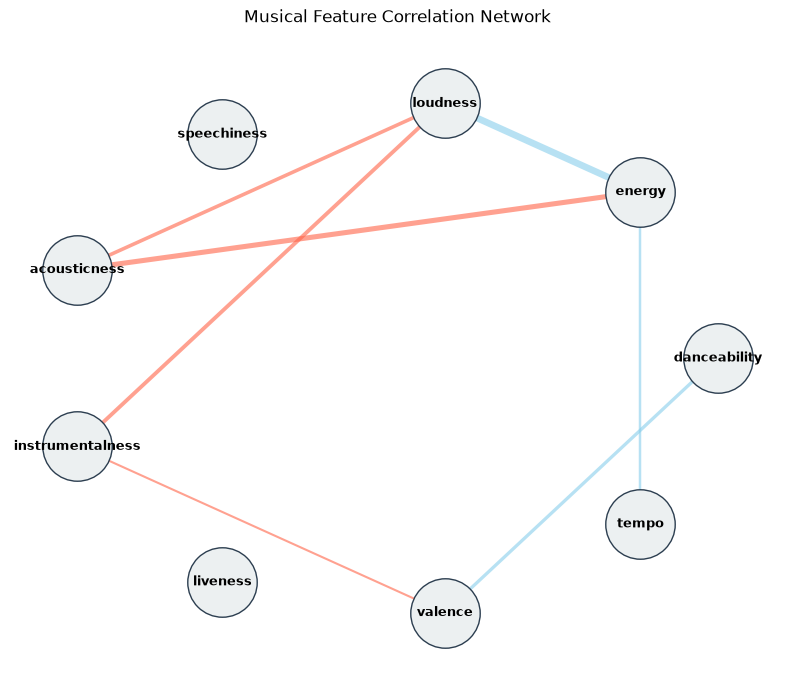

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Setup the Graph
G_features = nx.Graph()
G_features.add_nodes_from(continuous_features) # This ensures all 9 nodes stay!

# 2. Add edges based on your heatmap values
threshold = 0.20 # Lowered slightly so we see more "DNA"
for index, row in links_filtered.iterrows():
    if abs(row['value']) > threshold:
        color = 'tomato' if row['value'] < 0 else 'skyblue'
        G_features.add_edge(row['var1'], row['var2'], weight=abs(row['value']), color=color)

# 3. Visualization
plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G_features)

# Draw all nodes (even those without edges)
nx.draw_networkx_nodes(G_features, pos, node_size=2500, node_color='#ECF0F1', edgecolors='#2C3E50')
nx.draw_networkx_labels(G_features, pos, font_size=9, font_weight='bold')

# Draw edges
edges = G_features.edges(data=True)
if edges:
    colors = [d['color'] for u, v, d in edges]
    weights = [d['weight'] * 7 for u, v, d in edges]
    nx.draw_networkx_edges(G_features, pos, width=weights, edge_color=colors, alpha=0.6)

plt.title("Musical Feature Correlation Network", pad=20)
plt.axis('off')
plt.show()

# The Genre Similarity Graph (The "Map")

In [17]:
original_spotify = spotify.copy()
original_X_for_clustering = X_for_clustering.copy()

In [18]:
spotify = electronic_spotify
X_for_clustering = electronic_for_clustering

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Group by genre and calculate the mean for each feature
# This creates a 'profile' for each genre
genre_profiles = spotify.groupby('genre')[continuous_features].mean()
genre_names = genre_profiles.index.tolist()

# 2. Compute Cosine Similarity (Numpy Array)
sim_matrix = cosine_similarity(genre_profiles)

# 3. Use Numpy to extract the Upper Triangle (removes self-links and duplicates)
# k=1 means we skip the diagonal (self-similarity)
iu1 = np.triu_indices(len(genre_names), k=1)

links = pd.DataFrame({
    'genre_a': [genre_names[i] for i in iu1[0]],
    'genre_b': [genre_names[i] for i in iu1[1]],
    'weight': sim_matrix[iu1]
})

print(f"Successfully processed connections for {len(genre_names)} genres.")

Successfully processed connections for 20 genres.


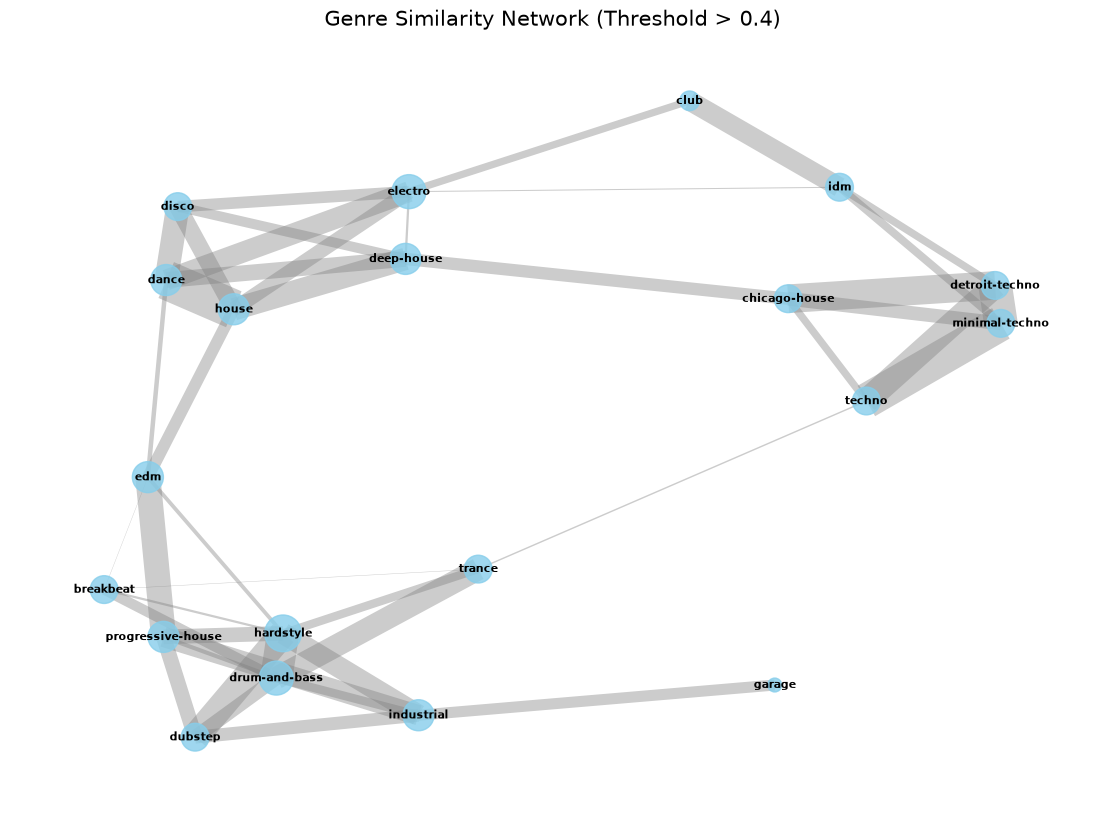

In [20]:
# Create the Graph
G_genre = nx.Graph()

# Set a strict threshold to see only the strongest overlaps
# Increase this if the graph is too crowded; decrease if it's too empty.
threshold = 0.40

for _, row in links.iterrows():
    if row['weight'] > threshold:
        # We subtract the threshold to make the visual weight more dramatic
        visual_weight = (row['weight'] - threshold) * 50 
        G_genre.add_edge(row['genre_a'], row['genre_b'], weight=row['weight'], vis_w=visual_weight)

# Visualization
plt.figure(figsize=(14, 10))

# Use Spring Layout - it pushes unrelated genres apart and pulls similar ones together
pos = nx.spring_layout(G_genre, k=0.5, iterations=50)

# Calculate node size based on 'degree' (how many similar genres it has)
d = dict(G_genre.degree)

nx.draw_networkx_nodes(G_genre, pos, node_size=[v * 100 for v in d.values()], node_color='skyblue', alpha=0.8)
nx.draw_networkx_labels(G_genre, pos, font_size=8, font_weight='bold')

# Draw edges with thickness based on similarity
edges = G_genre.edges(data=True)
weights = [d['vis_w'] for u, v, d in edges]
nx.draw_networkx_edges(G_genre, pos, width=weights, edge_color='grey', alpha=0.4)

plt.title(f"Genre Similarity Network (Threshold > {threshold})", fontsize=15)
plt.axis('off')
plt.show()

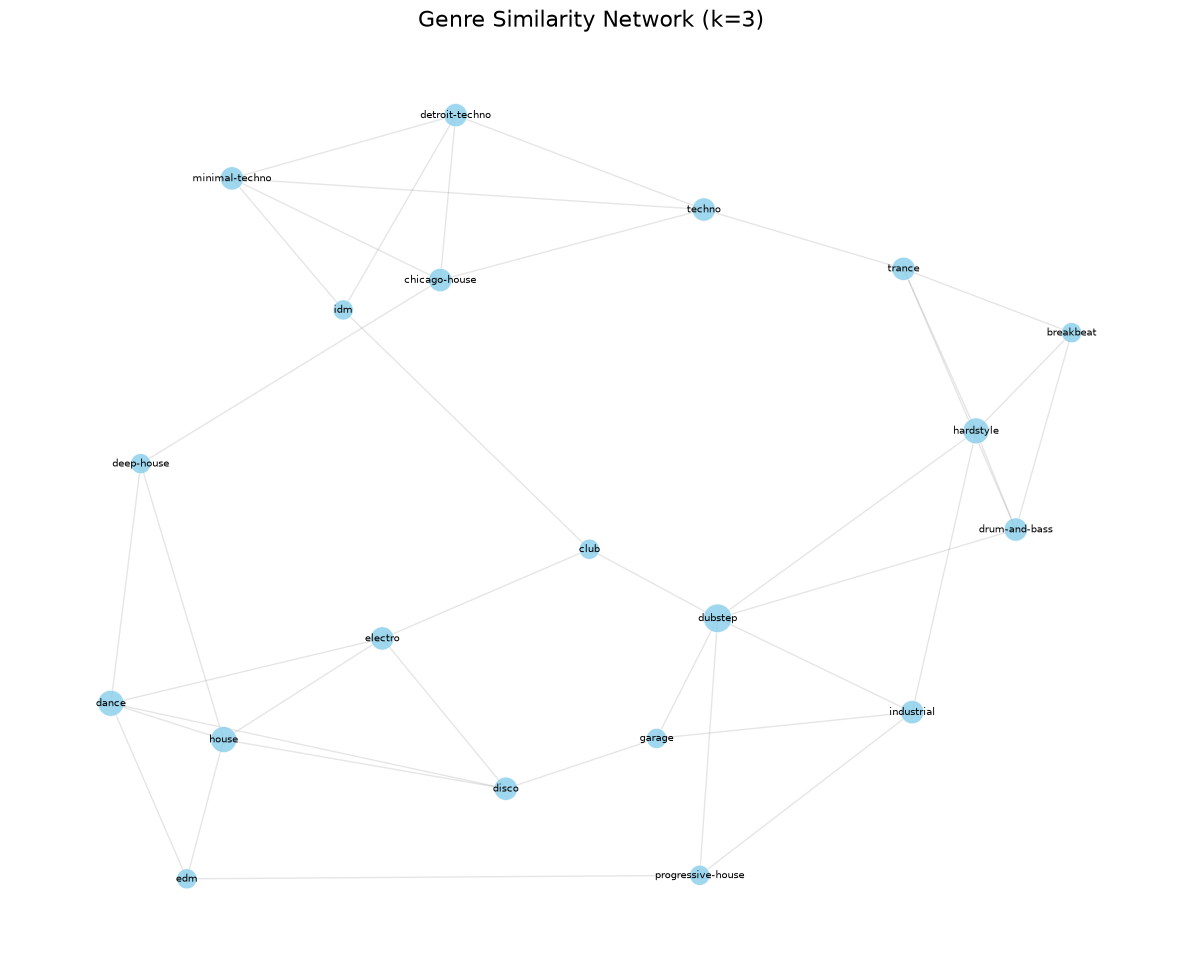

In [21]:
# --- VISUALIZATION: Top 3 Nearest Neighbors ---
G_genre = nx.Graph()

# Create a lookup for similarity
sim_df = pd.DataFrame(sim_matrix, index=genre_names, columns=genre_names)

# Connect each genre to its Top 3 most similar neighbors
k = 3
for genre in genre_names:
    # Get top k similarities (excluding itself)
    top_k = sim_df.loc[genre].sort_values(ascending=False)[1:k+1]
    for neighbor, score in top_k.items():
        G_genre.add_edge(genre, neighbor, weight=score)

# Draw the Map
plt.figure(figsize=(15, 12))
# kamada_kawai_layout is excellent for showing clusters in small-to-medium graphs
pos = nx.kamada_kawai_layout(G_genre)

# Node aesthetics
d = dict(G_genre.degree)
nx.draw_networkx_nodes(G_genre, pos, 
                       node_size=[v * 70 for v in d.values()], 
                       node_color='skyblue', 
                       alpha=0.8, 
                       edgecolors='white',
                       linewidths=0.5)

# Labels
nx.draw_networkx_labels(G_genre, pos, font_size=7, font_family='sans-serif')

# Edges
nx.draw_networkx_edges(G_genre, pos, alpha=0.2, edge_color='gray')

plt.title(f"Genre Similarity Network (k={k})", fontsize=16)
plt.axis('off')
plt.show()

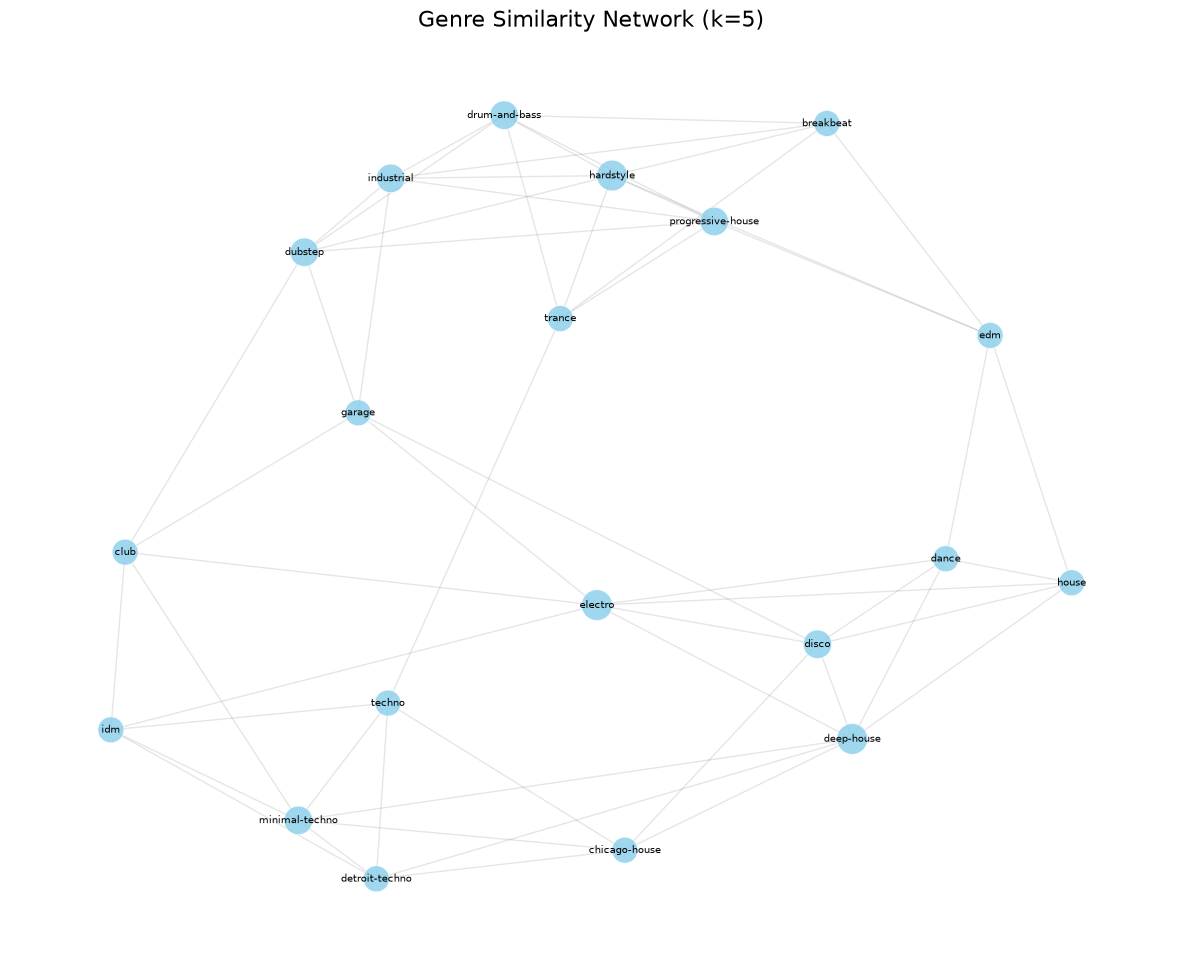

In [22]:
# --- VISUALIZATION: Top 3 Nearest Neighbors ---
G_genre = nx.Graph()

# Create a lookup for similarity
sim_df = pd.DataFrame(sim_matrix, index=genre_names, columns=genre_names)

# Connect each genre to its Top 3 most similar neighbors
k = 5
for genre in genre_names:
    # Get top k similarities (excluding itself)
    top_k = sim_df.loc[genre].sort_values(ascending=False)[1:k+1]
    for neighbor, score in top_k.items():
        G_genre.add_edge(genre, neighbor, weight=score)

# Draw the Map
plt.figure(figsize=(15, 12))
# kamada_kawai_layout is excellent for showing clusters in small-to-medium graphs
pos = nx.spring_layout(G_genre, k=0.5, iterations=50, seed=42)

# Node aesthetics
d = dict(G_genre.degree)
nx.draw_networkx_nodes(G_genre, pos, 
                       node_size=[v * 70 for v in d.values()], 
                       node_color='skyblue', 
                       alpha=0.8, 
                       edgecolors='white',
                       linewidths=0.5)

# Labels
nx.draw_networkx_labels(G_genre, pos, font_size=7, font_family='sans-serif')

# Edges
nx.draw_networkx_edges(G_genre, pos, alpha=0.2, edge_color='gray')

plt.title(f"Genre Similarity Network (k={k})", fontsize=16)
plt.axis('off')
plt.show()

In [23]:
import community.community_louvain as community_louvain # You may need to pip install python-louvain

# 1. Community Detection (Louvain)
# This finds 'clusters' of genres based on the network structure
partition = community_louvain.best_partition(G_genre)

# 2. Centrality Measures
# Betweenness: Who is the 'Bridge'?
betweenness = nx.betweenness_centrality(G_genre)
# Degree: Who is the most 'Standard' genre?
degree = nx.degree_centrality(G_genre)

# Print the results
stats_df = pd.DataFrame({
    'Community': pd.Series(partition),
    'Bridge_Score': pd.Series(betweenness),
    'Popularity_Score': pd.Series(degree)
}).sort_values(by='Community')

print(stats_df)


                   Community  Bridge_Score  Popularity_Score
chicago-house              0      0.029435          0.263158
detroit-techno             0      0.010526          0.263158
techno                     0      0.124366          0.263158
minimal-techno             0      0.038596          0.315789
club                       0      0.080897          0.263158
idm                        0      0.036355          0.263158
deep-house                 1      0.067446          0.368421
disco                      1      0.052956          0.315789
electro                    1      0.081514          0.368421
dance                      1      0.042333          0.263158
house                      1      0.042333          0.263158
industrial                 2      0.040769          0.315789
drum-and-bass              2      0.013952          0.315789
breakbeat                  2      0.023610          0.263158
edm                        2      0.109552          0.263158
trance                  

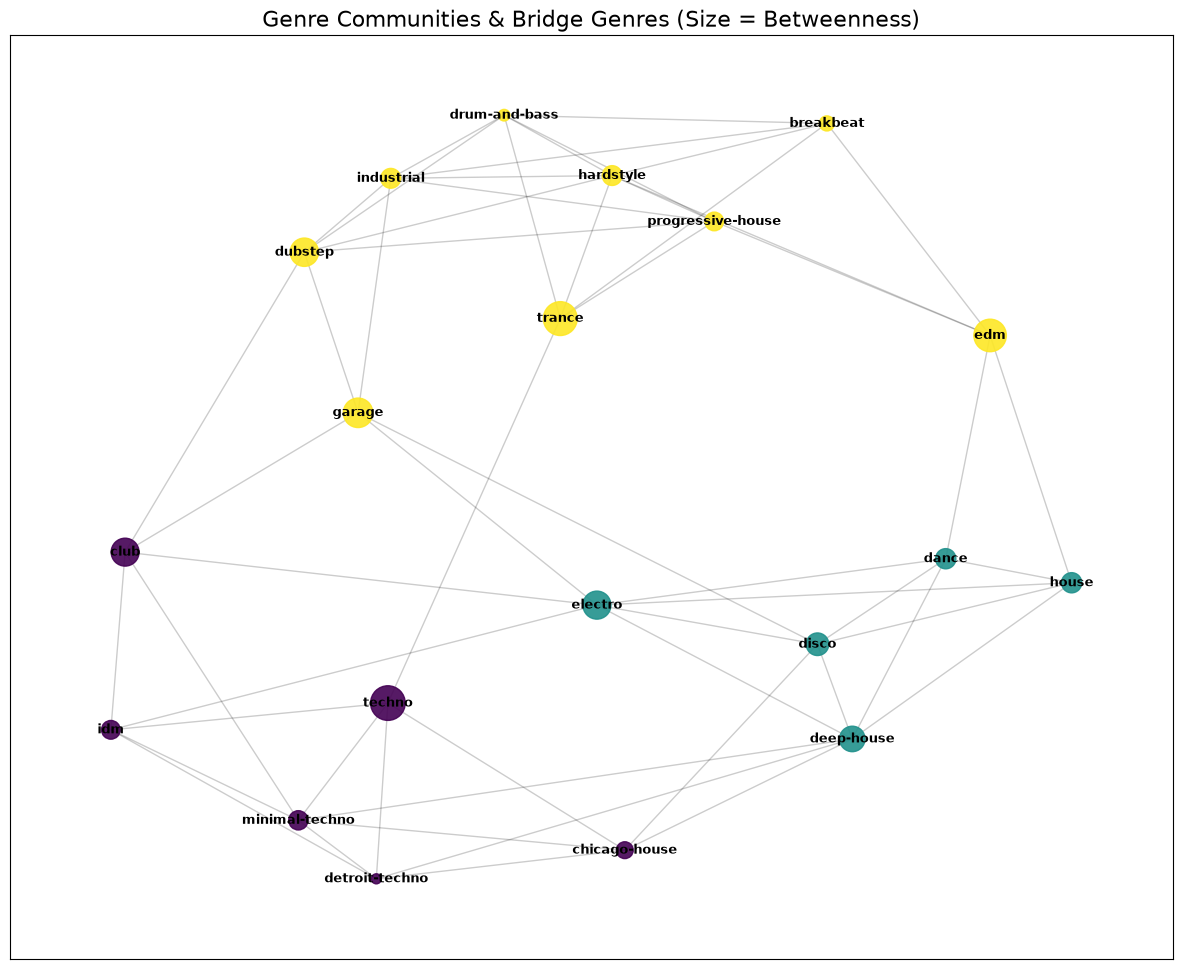

In [24]:
import numpy as np
from matplotlib.colors import ListedColormap

# 3. Visualization with Community Colors
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_genre, k=0.5, iterations=50, seed=42)

# Color nodes by their community
n_colors = max(partition.values()) + 1
cmap = ListedColormap(plt.get_cmap('viridis')(np.linspace(0, 1, n_colors)))
nx.draw_networkx_nodes(G_genre, pos, 
                       node_color=list(partition.values()), 
                       node_size=[v * 5000 for v in betweenness.values()], # Bigger nodes = more of a 'bridge'
                       cmap=cmap, alpha=0.9)

nx.draw_networkx_labels(G_genre, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G_genre, pos, alpha=0.2)

plt.title("Genre Communities & Bridge Genres (Size = Betweenness)", fontsize=16)
plt.show()

In [25]:
# Add the community labels to your genre_profiles
genre_profiles['community'] = pd.Series(partition)

# Calculate the average features for the 3 color-coded continents
community_profiles = genre_profiles.groupby('community').mean()

print("Community Acoustic Profiles:")
print(community_profiles)

Community Acoustic Profiles:
           danceability    energy  loudness  speechiness  acousticness  \
community                                                                
0              0.264585 -0.402797 -0.756255    -0.101749      0.120539   
1              0.339449 -0.374743  0.102782    -0.104620      0.340694   
2             -0.459956  0.351629  0.375619     0.083628     -0.201040   

           instrumentalness  liveness   valence     tempo  
community                                                  
0                  0.714011 -0.232456 -0.088945 -0.131362  
1                 -0.625608 -0.127426  0.403036 -0.308317  
2                 -0.156279  0.160544 -0.174503  0.285177  


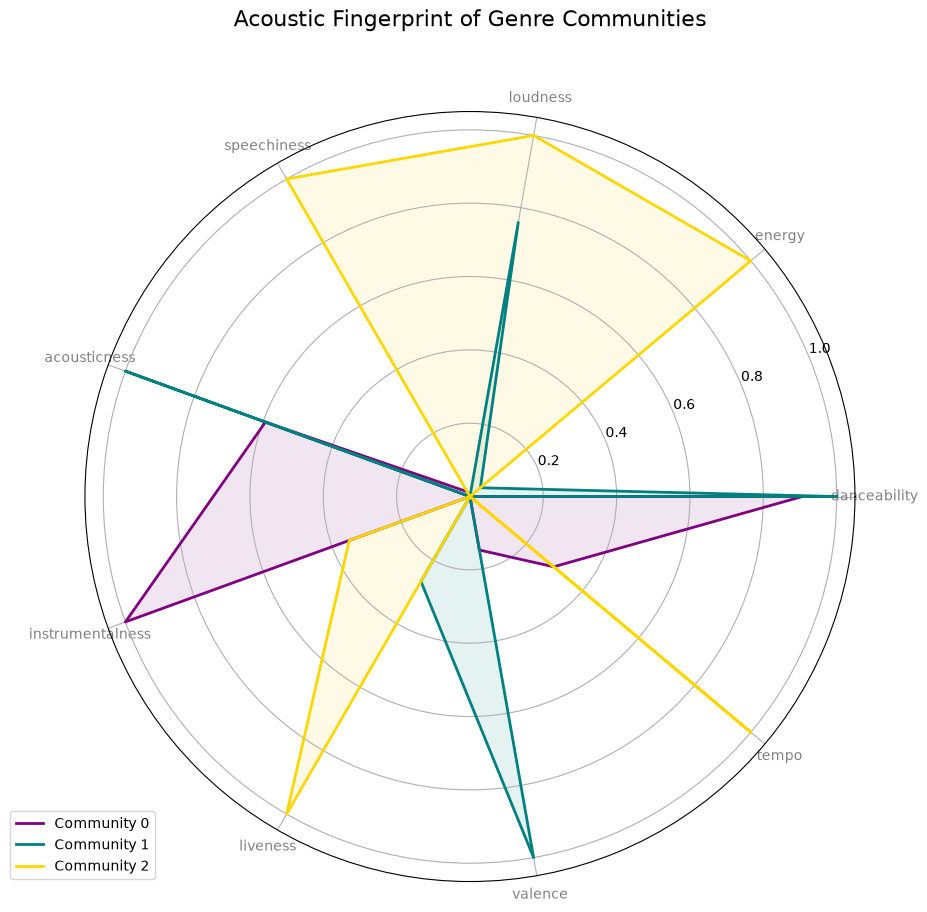

In [26]:
# 1. Prepare the data
# We use the genre_profiles and the partition (communities) from the previous step
from sklearn.preprocessing import MinMaxScaler


genre_profiles['community'] = pd.Series(partition)
community_means = genre_profiles.groupby('community').mean()

# Scale to 0-1 range for a better visual radar chart
scaler = MinMaxScaler()
plot_data = pd.DataFrame(scaler.fit_transform(community_means), 
                         columns=community_means.columns, 
                         index=community_means.index)

# 2. Radar Chart Function
def make_radar_chart(df):
    categories = list(df.columns)
    N = len(categories)
    
    # Angle for each axis
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Close the circle
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], categories, color='grey', size=10)
    
    # Community Colors (matching your graph)
    # 0 = Purple, 1 = Teal, 2 = Yellow (adjust based on your actual partition numbers)
    colors = ['purple', 'teal', 'gold', 'red', 'green'] 
    
    for i, row in df.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1] # Close the circle
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Community {i}", color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Acoustic Fingerprint of Genre Communities", size=16, y=1.1)
    plt.show()

make_radar_chart(plot_data)

In [27]:
from sklearn.neighbors import NearestNeighbors

# 1. Build k-NN on the full dataset (k=11 because the first neighbor is always the song itself)
knn = NearestNeighbors(n_neighbors=11, metric='cosine')
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Calculate Purity for every song
# We look at the genre of the song and compare it to its 10 neighbors
genres = spotify['genre'].values
purity_scores = []

for i in range(len(indices)):
    own_genre = genres[i]
    neighbor_genres = genres[indices[i][1:]] # Skip self
    matching_neighbors = np.sum(neighbor_genres == own_genre)
    purity_scores.append(matching_neighbors / 10.0)

spotify['purity'] = purity_scores

# 3. Aggregate: Which Genres are the most "Pure"?
genre_purity = spotify.groupby('genre')['purity'].mean().sort_values(ascending=False)

print("Top 5 'Purest' Genres (Mathematically distinct):")
print(genre_purity.head(5))

print("\nTop 5 'Confused' Genres (High overlap/Imposters):")
print(genre_purity.tail(5))

Top 5 'Purest' Genres (Mathematically distinct):
genre
drum-and-bass     0.457486
edm               0.420544
hardstyle         0.409318
idm               0.391858
minimal-techno    0.259290
Name: purity, dtype: float64

Top 5 'Confused' Genres (High overlap/Imposters):
genre
dance                0.118107
progressive-house    0.093796
dubstep              0.090514
techno               0.070823
house                0.031343
Name: purity, dtype: float64


In [28]:
count_number_eletronic = spotify[spotify['genre'] == 'electronic'].shape[0]
print(f"Number of 'electronic' songs in the dataset: {count_number_eletronic}")

Number of 'electronic' songs in the dataset: 0


# Graph 3: The Song-to-Song k-NN Graph (The "Deep Dive")

In [29]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# 1. Build the k-NN for 100k songs (k=10)
# Use the dataframe where you kept the 'genre' column for labels
knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Create the Graph
G_songs = nx.Graph()

# 3. Add edges (this may take a minute for 1M edges)
# We use the index of the songs as nodes
for i, neighbors in enumerate(indices):
    for neighbor in neighbors[1:]: # Skip the first one because it's the song itself
        G_songs.add_edge(i, neighbor)

# 4. Attach genre labels to the nodes
# Assuming 'spotify' is your original df with the 'genre' column
genre_labels = spotify['genre'].to_dict()
nx.set_node_attributes(G_songs, genre_labels, 'genre')

# 5. CALCULATE ASSORTATIVITY
assortativity = nx.attribute_assortativity_coefficient(G_songs, 'genre')

print(f"The Genre Assortativity of the Spotify Dataset is: {assortativity:.4f}")

The Genre Assortativity of the Spotify Dataset is: 0.1917


Efficient Graph Construction

In [30]:
import numpy as np
import pandas as pd
import networkx as nx
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors

# 1. Build the k-NN (k=10)
# We use Cosine because music is about the 'ratio' of features
knn = NearestNeighbors(n_neighbors=11, metric='cosine', n_jobs=-1)
knn.fit(X_for_clustering)
distances, indices = knn.kneighbors(X_for_clustering)

# 2. Build the Adjacency Matrix (Sparse)
rows = np.repeat(np.arange(indices.shape[0]), indices.shape[1]-1)
cols = indices[:, 1:].flatten() # Skip self-link
data = np.ones(len(rows))

adj_matrix = sp.csr_matrix((data, (rows, cols)), shape=(len(spotify), len(spotify)))

# 3. Create the NetworkX object (for metrics)
G_songs = nx.from_scipy_sparse_array(adj_matrix)

In [31]:
# Attach genre labels to nodes
genre_dict = spotify['genre'].to_dict()
nx.set_node_attributes(G_songs, genre_dict, 'genre')

# Calculate Assortativity
global_assortativity = nx.attribute_assortativity_coefficient(G_songs, 'genre')
print(f"Genre Assortativity: {global_assortativity:.4f}")

Genre Assortativity: 0.1898


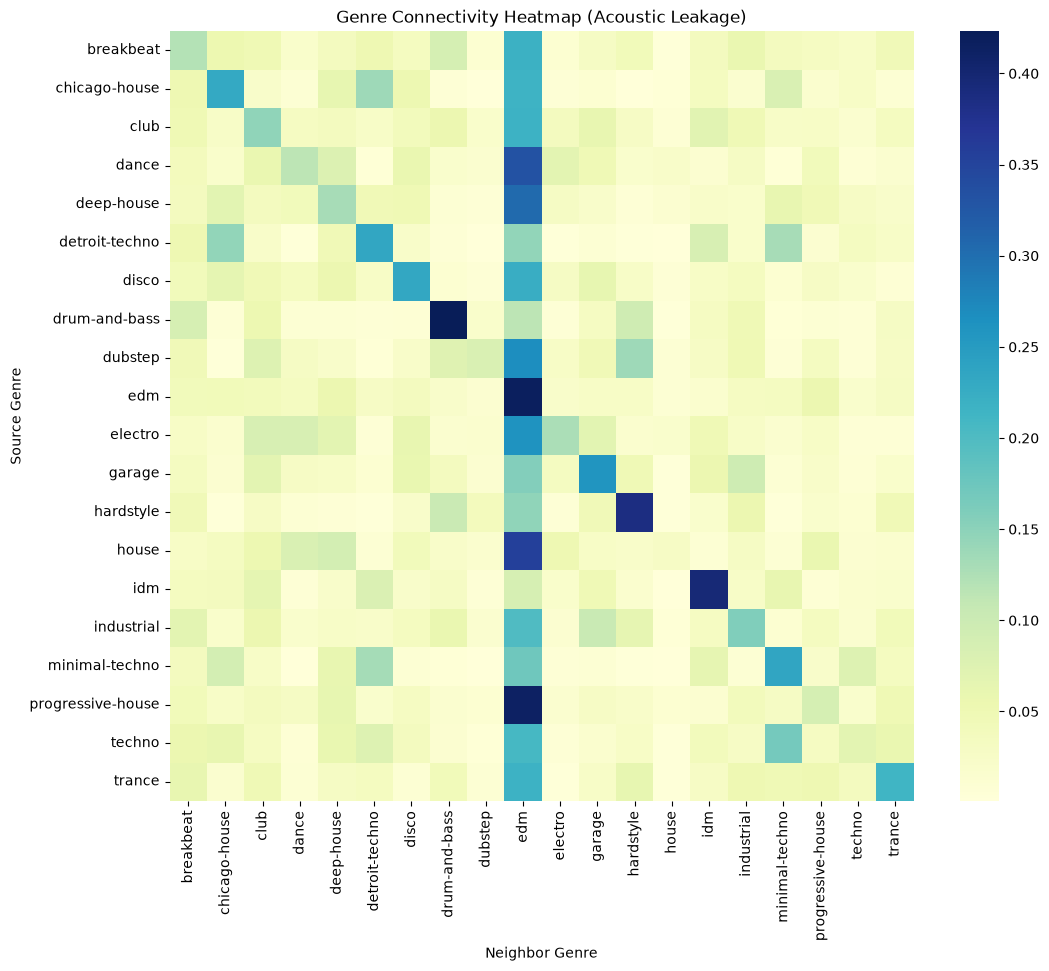

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

genre_dict = spotify['genre'].to_dict()
nx.set_node_attributes(G_songs, genre_dict, 'genre')

# 2. Get your unique genres and build an explicit mapping dictionary
genres_list = sorted(spotify['genre'].unique())
genre_mapping = {genre: i for i, genre in enumerate(genres_list)}

# 3. Get the mixing matrix using the explicit mapping
# This guarantees that index i in the matrix matches index i in genres_list
mixing_matrix = nx.attribute_mixing_matrix(G_songs, 'genre', mapping=genre_mapping)

# 4. Convert to DataFrame for visualization
mixing_df = pd.DataFrame(mixing_matrix, index=genres_list, columns=genres_list)

# 5. Normalize by row
mixing_df_norm = mixing_df.div(mixing_df.sum(axis=1), axis=0).fillna(0)

# 6. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mixing_df_norm, cmap='YlGnBu', annot=False)
plt.title("Genre Connectivity Heatmap (Acoustic Leakage)")
plt.xlabel("Neighbor Genre")
plt.ylabel("Source Genre")
plt.show()

In [34]:
import numpy as np

# 1. Force the genre column into a vanilla NumPy "Object" array
# .tolist() is the most reliable way to strip all Pandas-specific behaviors
all_genres_np = np.array(spotify['genre'].tolist(), dtype=object)

# 2. Map neighbor indices to genres -> Result is a (100000, 10) NumPy array
neighbor_genres = all_genres_np[indices[:, 1:]]

# 3. Get own genres and reshape -> Result is a (100000, 1) NumPy array
own_genres = all_genres_np.reshape(-1, 1)

# 4. Perform the comparison
# Because these are now pure NumPy object arrays, != will work perfectly with broadcasting
mismatches_matrix = (neighbor_genres != own_genres)

# 5. Sum the True values across the rows (axis 1)
mismatches = mismatches_matrix.sum(axis=1)

# 6. Assign the score back to your dataframe
spotify['boundary_index'] = mismatches / 10.0

# 7. Show the results
print("Success! Boundary Index calculated.")
print(spotify[['name', 'artists', 'genre', 'boundary_index']].head())

Success! Boundary Index calculated.
                            name                   artists           genre  \
0  Böxig Leise - Pig & Dan Remix  Paul Kalkbrenner;Pig&Dan  minimal-techno   
1                           Tief          Paul Kalkbrenner  minimal-techno   
2      Find Me - Sigma VIP Remix               Sigma;Birdy   drum-and-bass   
3                      Addiction                    Dither             idm   
4       Hips, Tits, Lips, Power!                   Pigface      industrial   

   boundary_index  
0             0.8  
1             0.7  
2             0.1  
3             0.6  
4             0.3  


In [35]:
# A low average boundary index means the genre is very distinct/pure
genre_stability = spotify.groupby('genre')['boundary_index'].mean().sort_values()

print("Genre Stability Score (Lower = More Acoustically Distinct):")
print(genre_stability)

Genre Stability Score (Lower = More Acoustically Distinct):
genre
drum-and-bass        0.542514
edm                  0.579456
hardstyle            0.590682
idm                  0.608142
minimal-techno       0.740710
garage               0.741359
disco                0.754616
chicago-house        0.757741
detroit-techno       0.761848
trance               0.782544
industrial           0.840915
club                 0.856131
deep-house           0.869399
electro              0.871094
breakbeat            0.880524
dance                0.881893
progressive-house    0.906204
dubstep              0.909486
techno               0.929177
house                0.968657
Name: boundary_index, dtype: float64


In [36]:
# Boundary Index 0.0 means all 10 neighbors are the same genre
archetypes = spotify[spotify['boundary_index'] == 0.0]
print(f"Found {len(archetypes)} archetype songs.")
print(archetypes[['name', 'artists', 'genre']].sample(10))

Found 165 archetype songs.
                          name                                artists  \
4217                  Symphony                       Sick Individuals   
12165  Banaan - Ruthless Remix  Jebroer;Stepherd;Skinto;Jayh;Ruthless   
18475                   Carver                         Jurassic Shark   
16058                    Crush                               Pendulum   
7754                     Ghost                            Delta Heavy   
1269                     Hydra                            Delta Heavy   
6525                      GURU                          Maski & Banga   
3999         Azukiiro No Kaori                          Susumu Yokota   
11911        Show Me Your Love                              Firebeatz   
5651                  Hangover                            Thomas Gold   

               genre  
4217             edm  
12165      hardstyle  
18475         garage  
16058  drum-and-bass  
7754   drum-and-bass  
1269   drum-and-bass  
6525    

In [37]:
# Boundary Index 1.0 means NONE of the neighbors share the song's genre
crossovers = spotify[spotify['boundary_index'] >= 0.9]
print("Crossover / Bridge Songs (Acoustic Imposters):")
print(crossovers[['name', 'artists', 'genre']].head(10))

Crossover / Bridge Songs (Acoustic Imposters):
                            name                  artists              genre
7                F*CKING SOCIETY                 Hardwell  progressive-house
9                           Home              Robert Hood      chicago-house
11  Lüg nochmal - Discofox Remix  Allessa;Hubert Molander              disco
12                   I Was Wrong         Black Tambourine               club
15             Life - Radio Edit             NG Rezonance             trance
21                 World Is Mine                  Showtek          hardstyle
23                    Going Down     Nick Novity;D-Ceptor          hardstyle
29                   Take a Hold                  Calippo         deep-house
31                     Full Moon             DREAMCATCHER                edm
34                       Carrage              Luke Abbott                idm


In [38]:
import community as community_louvain

# This finds communities based on song connectivity
partition = community_louvain.best_partition(G_songs)
spotify['network_community'] = spotify.index.map(partition)

# Now, let's see how many 'Network Communities' represent each 'Spotify Genre'
community_agreement = spotify.groupby('genre')['network_community'].nunique()
print("Number of acoustic communities per genre:")
print(community_agreement.sort_values(ascending=False).head(10))

Number of acoustic communities per genre:
genre
breakbeat         16
chicago-house     16
club              16
deep-house        16
trance            16
detroit-techno    16
disco             16
drum-and-bass     16
edm               16
garage            16
Name: network_community, dtype: int64


In [39]:
# 1. Create a Cross-tabulation (Genre vs Community)
# This shows exactly how many songs of Genre X are in Community Y
ctab = pd.crosstab(spotify['genre'], spotify['network_community'])

# 2. Calculate the "Concentration"
# What % of the genre is in its most populated community?
concentration = (ctab.max(axis=1) / ctab.sum(axis=1)).sort_values(ascending=False)

# 3. Find the "Primary Community ID" for each genre
primary_comm = ctab.idxmax(axis=1)

enrichment_df = pd.DataFrame({
    'Primary_Community': primary_comm,
    'Concentration_Score': concentration
})

print("Genre Concentration (How much a genre 'sticks' to one acoustic community):")
print(enrichment_df)

Genre Concentration (How much a genre 'sticks' to one acoustic community):
                   Primary_Community  Concentration_Score
genre                                                    
breakbeat                          5             0.109948
chicago-house                      1             0.213389
club                               3             0.141649
dance                             13             0.185185
deep-house                         0             0.165027
detroit-techno                     1             0.315217
disco                              0             0.232770
drum-and-bass                     11             0.328962
dubstep                            2             0.256917
edm                               10             0.131344
electro                           14             0.377604
garage                             2             0.202765
hardstyle                          2             0.298864
house                             14             0.1641

In [40]:
# Function to get the top genres for a specific community
def get_community_makeup(comm_id, top_n=3):
    subset = spotify[spotify['network_community'] == comm_id]
    makeup = subset['genre'].value_counts(normalize=True).head(top_n)
    return ", ".join([f"{g} ({p:.1%})" for g, p in makeup.items()])

# Apply to all 16 communities
community_profiles = pd.DataFrame(index=range(16))
community_profiles['Top_Genres'] = community_profiles.index.map(get_community_makeup)

print("What are the communities actually made of?")
print(community_profiles)

What are the communities actually made of?
                                           Top_Genres
0   edm (23.9%), chicago-house (15.4%), disco (13.8%)
1   minimal-techno (21.8%), detroit-techno (19.8%)...
2   hardstyle (18.5%), drum-and-bass (17.3%), edm ...
3         edm (33.8%), hardstyle (10.0%), club (8.3%)
4   edm (31.2%), minimal-techno (14.9%), detroit-t...
5       edm (29.3%), trance (11.2%), breakbeat (9.1%)
6           club (17.1%), idm (11.0%), trance (10.6%)
7   edm (40.3%), deep-house (8.5%), chicago-house ...
8   edm (24.5%), chicago-house (21.1%), detroit-te...
9   edm (45.1%), progressive-house (9.6%), deep-ho...
10  edm (41.1%), hardstyle (13.7%), progressive-ho...
11  drum-and-bass (37.3%), breakbeat (10.3%), tran...
12       edm (31.7%), disco (16.7%), breakbeat (7.1%)
13     edm (23.2%), industrial (12.1%), garage (9.9%)
14        edm (24.7%), disco (11.9%), electro (11.5%)
15             idm (48.5%), edm (8.5%), garage (8.4%)


In [41]:
from scipy.stats import entropy

def calculate_entropy(comm_id):
    # Get the distribution of genres in this community
    probs = spotify[spotify['network_community'] == comm_id]['genre'].value_counts(normalize=True)
    return entropy(probs)

community_profiles['Entropy'] = community_profiles.index.map(calculate_entropy)
print(community_profiles.sort_values(by='Entropy'))

                                           Top_Genres   Entropy
15             idm (48.5%), edm (8.5%), garage (8.4%)  1.915289
9   edm (45.1%), progressive-house (9.6%), deep-ho...  2.144506
10  edm (41.1%), hardstyle (13.7%), progressive-ho...  2.153207
8   edm (24.5%), chicago-house (21.1%), detroit-te...  2.181721
11  drum-and-bass (37.3%), breakbeat (10.3%), tran...  2.188061
1   minimal-techno (21.8%), detroit-techno (19.8%)...  2.235455
7   edm (40.3%), deep-house (8.5%), chicago-house ...  2.241413
4   edm (31.2%), minimal-techno (14.9%), detroit-t...  2.270358
2   hardstyle (18.5%), drum-and-bass (17.3%), edm ...  2.349065
12       edm (31.7%), disco (16.7%), breakbeat (7.1%)  2.355653
14        edm (24.7%), disco (11.9%), electro (11.5%)  2.383220
0   edm (23.9%), chicago-house (15.4%), disco (13.8%)  2.386615
5       edm (29.3%), trance (11.2%), breakbeat (9.1%)  2.436001
3         edm (33.8%), hardstyle (10.0%), club (8.3%)  2.450132
13     edm (23.2%), industrial (12.1%), 

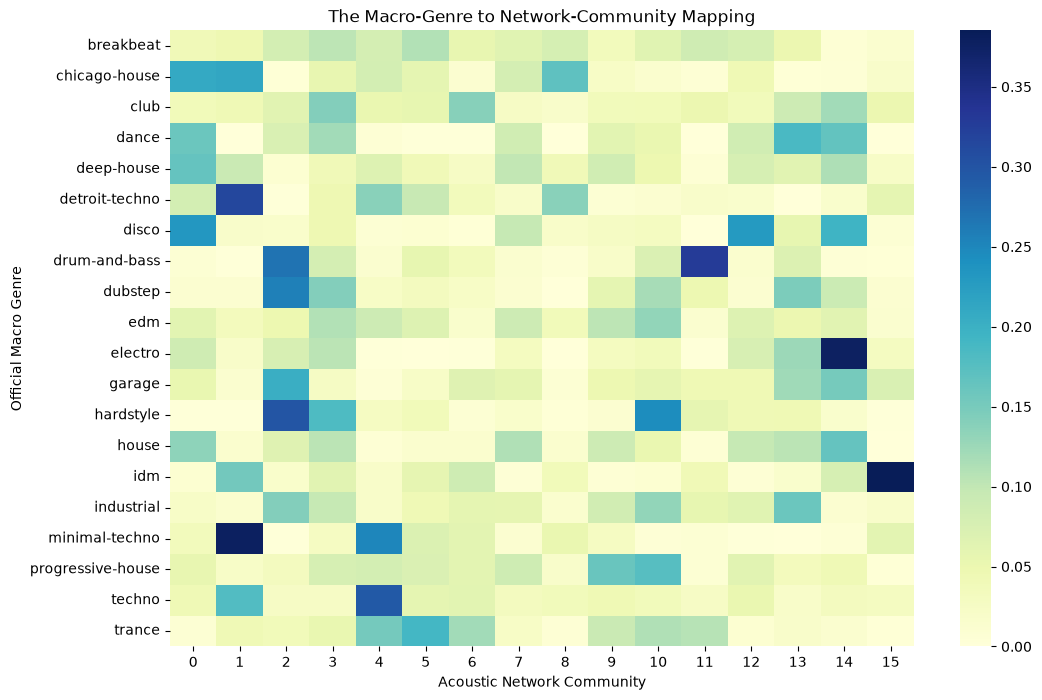

In [42]:
import seaborn as sns

# Normalize the cross-tab so rows sum to 1
ctab_norm = ctab.div(ctab.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(ctab_norm, cmap="YlGnBu", annot=False)
plt.title("The Macro-Genre to Network-Community Mapping")
plt.ylabel("Official Macro Genre")
plt.xlabel("Acoustic Network Community")
plt.show()

### Page Rank

In [43]:
# Calculate how many times each song was chosen as a neighbor by others
# (Using the sparse adjacency matrix columns)
in_degrees = np.array(adj_matrix.sum(axis=0)).flatten()
spotify['archetype_score'] = in_degrees

# Top "Archetype" songs (The most typical sounding tracks)
print("Top Archetype Songs:")
print(spotify.sort_values(by='archetype_score', ascending=False)[['name', 'artists', 'genre']].head(5))

Top Archetype Songs:
                                    name                 artists  \
16848  I Need - Wilkinson & Metrik Remix  Wilkinson;Hayla;Metrik   
2567               I Found You (Neptune)           EDX;Jess Ball   
1265                 Confide (Contour 1)             Booka Shade   
13398                Pfau - Original Mix               Sasch BBC   
17516                            Balance                Band&dos   

                genre  
16848   drum-and-bass  
2567       deep-house  
1265   minimal-techno  
13398             edm  
17516             edm  


In [44]:
# Compute PageRank on the 100k song graph
# (Using NetworkX's sparse-friendly implementation)
pagerank_scores = nx.pagerank(G_songs, alpha=0.85)

# Map back to dataframe
spotify['pagerank'] = spotify.index.map(pagerank_scores)

print("Top PageRank Songs (The Acoustic Core):")
print(spotify.sort_values(by='pagerank', ascending=False)[['name', 'artists', 'genre']].head(5))

Top PageRank Songs (The Acoustic Core):
                                    name                  artists  \
4668                           Cyberpunk              Extra Terra   
16848  I Need - Wilkinson & Metrik Remix   Wilkinson;Hayla;Metrik   
2567               I Found You (Neptune)            EDX;Jess Ball   
1265                 Confide (Contour 1)              Booka Shade   
2271                          OI F#KN OI  Code Black;Toneshifterz   

                genre  
4668             club  
16848   drum-and-bass  
2567       deep-house  
1265   minimal-techno  
2271        hardstyle  


In [45]:
# Compute clustering coefficient for nodes (subset or full if fast enough)
clustering_coeffs = nx.clustering(G_songs)
spotify['clustering'] = spotify.index.map(clustering_coeffs)

print("Highest Clustering (Tightest sub-genre niches):")
print(spotify.sort_values(by='clustering', ascending=False)[['name', 'artists', 'genre']].head(5))

Highest Clustering (Tightest sub-genre niches):
                                             name  \
1698                                  Hellifornia   
17660                                      Closer   
17916                                   Shockwave   
9748   Tremor - Sensation 2014 Anthem; Radio Edit   
17217                              Shadow Dancing   

                                                 artists              genre  
1698                                       Gesaffelstein               club  
17660                                       Magnificence                edm  
17916                                        Dither;Nolz                idm  
9748   Dimitri Vegas & Like Mike;Martin Garrix;Like Mike  progressive-house  
17217                                       Theo Parrish     detroit-techno  


In [46]:
import random

# Take a random sample of 5,000 nodes to estimate 'global' bridges
sample_nodes = random.sample(list(G_songs.nodes()), 5000)
subgraph = G_songs.subgraph(sample_nodes)

betweenness = nx.betweenness_centrality(subgraph, k=100) # k=100 is the number of nodes to sample per step
spotify['betweenness'] = spotify.index.map(betweenness)
spotify['betweenness'] = spotify['betweenness'].fillna(0)

print("Top 10 Crossover Bridges:")
print(spotify.sort_values(by='betweenness', ascending=False)[['name', 'artists', 'genre']].head(10))

Top 10 Crossover Bridges:
                                                 name              artists  \
2355                                          Nikamma               Lifafa   
9904                                      Second Peng             Autechre   
17379                                   All Your Love                Jakob   
17419                                             One               MMOTHS   
954                       No. 1. - Lent Et Douloureux                 Isan   
16923  Dreams (Mix Cut) - Nicholson’s Cathedral Remix     Quench;Nicholson   
11857                                       In My Car  The Magnetic Fields   
5339                                       BODYGUARD!            JPEGMAFIA   
1899                                    Save the Rave      Tommie Sunshine   
13800                                        Baby Boo           Zephyrtone   

            genre  
2355      electro  
9904          idm  
17379      garage  
17419         idm  
954           i

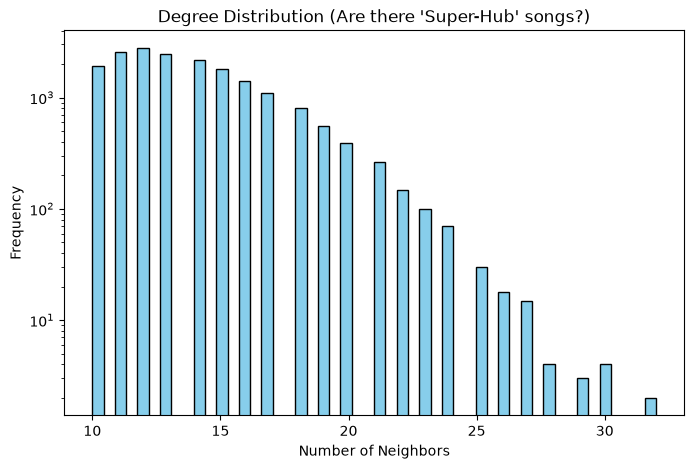

In [47]:
degrees = [d for n, d in G_songs.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')
plt.title("Degree Distribution (Are there 'Super-Hub' songs?)")
plt.xlabel("Number of Neighbors")
plt.ylabel("Frequency")
plt.yscale('log') # Log scale is standard for power-law detection
plt.show()

### COmmunities

In [48]:
import community.community_louvain as community_louvain

# Calculate the Modularity Score
mod_score = community_louvain.modularity(partition, G_songs)
print(f"Graph Modularity: {mod_score:.4f}")

Graph Modularity: 0.7798


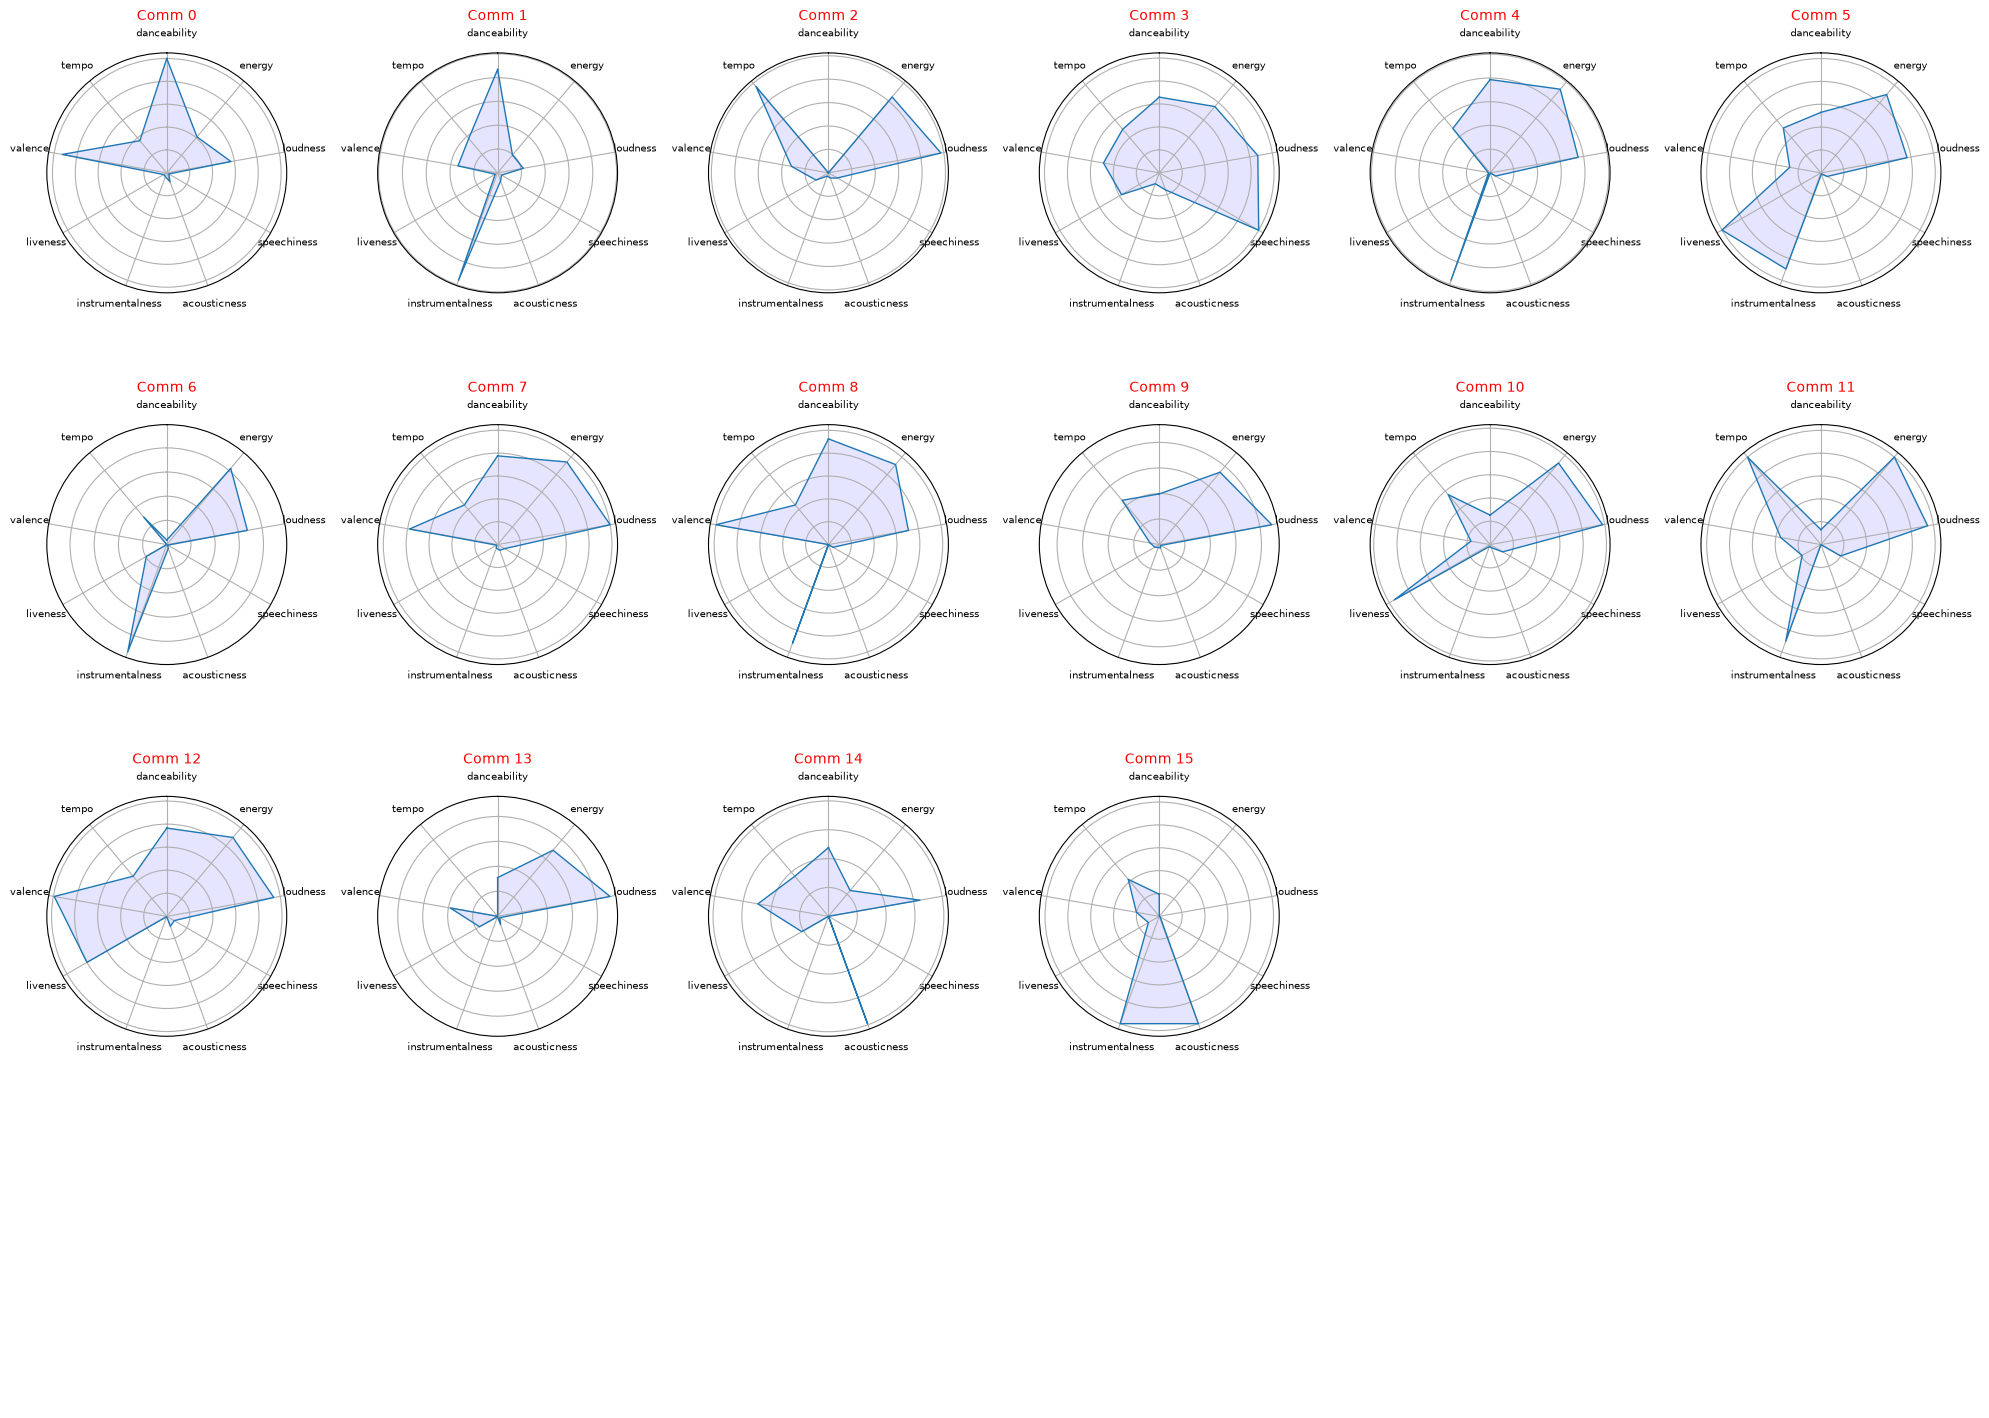

In [49]:
from sklearn.preprocessing import MinMaxScaler

# 1. Calculate average features per community
comm_features = spotify.groupby('network_community')[continuous_features].mean()

# 2. Scale 0-1 for radar chart
scaler = MinMaxScaler()
comm_scaled = pd.DataFrame(scaler.fit_transform(comm_features), columns=comm_features.columns)

# 3. Plotting function for "Small Multiples"
def plot_community_radars(df):
    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Create a grid (e.g., 4 rows x 6 columns)
    fig, axes = plt.subplots(4, 6, figsize=(20, 15), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    for i in range(len(df)):
        ax = axes[i]
        values = df.iloc[i].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=1, linestyle='solid')
        ax.fill(angles, values, 'b', alpha=0.1)
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=7)
        ax.set_title(f"Comm {i}", size=10, color='red')
        ax.set_yticklabels([]) # Hide radial labels for clarity

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_community_radars(comm_scaled)

In [50]:
# Degree centrality tells us which song has the most connections WITHIN the network
# (In a k-NN graph, degree is usually k, so we look for PageRank or 'Local Purity')

# Calculate Local Purity: How many of a song's 10 neighbors are in the SAME community?
own_comm = spotify['network_community'].values.reshape(-1, 1)
neighbor_comm = spotify['network_community'].values[indices[:, 1:]]
local_purity = np.sum(neighbor_comm == own_comm, axis=1) / 10.0
spotify['comm_purity'] = local_purity

# Top Archetypes (Purity = 1.0 means the song is 'Deep' inside its community)
archetypes = spotify.sort_values(by='comm_purity', ascending=False).head(10)
print("Top Archetype Songs (The 'Soul' of their respective communities):")
print(archetypes[['name', 'artists', 'genre', 'network_community']])

Top Archetype Songs (The 'Soul' of their respective communities):
                                                    name  \
18672                                 This Is Who We Are   
18655                  Immortals - (Chris Howland Remix)   
18654                                        Work Groove   
18650  Perfect (For Somebody Else) [feat. Dewain Whit...   
18649                                     Andrew's Break   
18647                             Take Me - Original Mix   
18644                                            Megator   
18643             Out of Body Experience - Globe All Mix   
32                       Came to Play - Original Version   
29                                           Take a Hold   

                               artists           genre  network_community  
18672                 Dash Berlin;Syzz          trance                 10  
18655                           Terine             edm                  3  
18654      Mark Farina;Homero Espinosa   chic

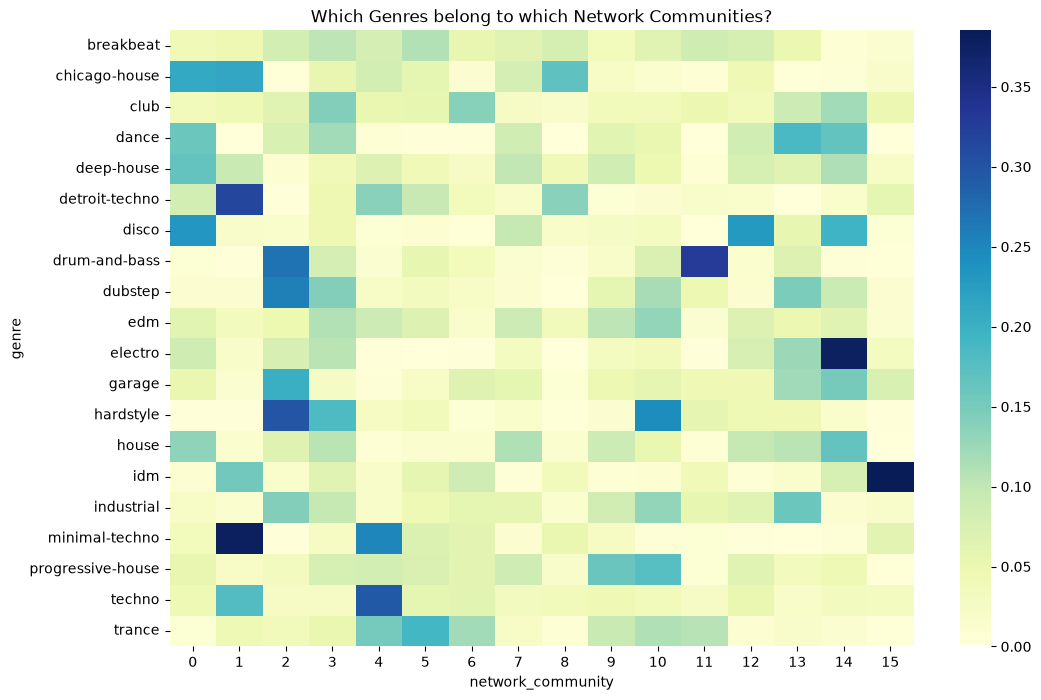

In [51]:
# Create a heatmap of Genre vs Community
# If a community is 'pure', it will have one dark square.
plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(spotify['genre'], spotify['network_community'], normalize='index'), 
            cmap="YlGnBu", annot=False)
plt.title("Which Genres belong to which Network Communities?")
plt.show()

In [52]:
# 1. Prepare arrays for vectorized calculation
comm_labels = spotify['network_community'].values
# 'indices' was generated by your k-NN step (100k x 11)
neighbor_indices = indices[:, 1:] # Skip the first column (self)

# 2. Map neighbor indices to their community IDs
# This creates a 100k x 10 matrix of community IDs
neighbor_comms = comm_labels[neighbor_indices]

# 3. Compare each song's community to its neighbors' communities
# Using broadcasting: (100k, 10) == (100k, 1)
is_same_comm = (neighbor_comms == comm_labels.reshape(-1, 1))

# 4. Calculate Purity (0.0 to 1.0)
spotify['community_purity'] = np.mean(is_same_comm, axis=1)

print(f"Average Community Purity: {spotify['community_purity'].mean():.4f}")

Average Community Purity: 0.8555


In [53]:
print(f"Variance Community Purity: {spotify['community_purity'].var():.4f}")

Variance Community Purity: 0.0376


In [54]:
# 1. Count how many times each index appears in the neighbor matrix
# np.bincount counts occurrences of integers in an array
in_degree_counts = np.bincount(neighbor_indices.flatten(), minlength=len(spotify))

# 2. Assign back to dataframe
spotify['in_degree'] = in_degree_counts

print("Top 5 Acoustic Magnets (Highest In-Degree):")
print(spotify.sort_values(by='in_degree', ascending=False)[['name', 'artists', 'genre', 'in_degree']].head())

Top 5 Acoustic Magnets (Highest In-Degree):
                                    name                 artists  \
16848  I Need - Wilkinson & Metrik Remix  Wilkinson;Hayla;Metrik   
2567               I Found You (Neptune)           EDX;Jess Ball   
1265                 Confide (Contour 1)             Booka Shade   
13398                Pfau - Original Mix               Sasch BBC   
17516                            Balance                Band&dos   

                genre  in_degree  
16848   drum-and-bass         32  
2567       deep-house         32  
1265   minimal-techno         30  
13398             edm         30  
17516             edm         30  


In [55]:
# 1. Count how many times each index appears in the neighbor matrix
# np.bincount counts occurrences of integers in an array
in_degree_counts = np.bincount(neighbor_indices.flatten(), minlength=len(spotify))

# 2. Assign back to dataframe
spotify['in_degree'] = in_degree_counts

print("Top 5 Acoustic Magnets (Highest In-Degree):")
print(spotify.sort_values(by='in_degree', ascending=False)[['name', 'artists', 'genre', 'in_degree']].head())

Top 5 Acoustic Magnets (Highest In-Degree):
                                    name                 artists  \
16848  I Need - Wilkinson & Metrik Remix  Wilkinson;Hayla;Metrik   
2567               I Found You (Neptune)           EDX;Jess Ball   
1265                 Confide (Contour 1)             Booka Shade   
13398                Pfau - Original Mix               Sasch BBC   
17516                            Balance                Band&dos   

                genre  in_degree  
16848   drum-and-bass         32  
2567       deep-house         32  
1265   minimal-techno         30  
13398             edm         30  
17516             edm         30  


In [56]:
# Which communities are the most 'solid'?
comm_stats = spotify.groupby('network_community').agg({
    'community_purity': 'mean',
    'in_degree': 'mean',
    'danceability': 'mean' # Example of adding an audio feature
}).sort_values(by='community_purity', ascending=False)

print(comm_stats)

                   community_purity  in_degree  danceability
network_community                                           
1                          0.886485  10.185666      0.635875
15                         0.885151  10.013141     -0.624335
14                         0.874704   9.933597     -0.096804
2                          0.874209   9.903725     -0.985148
4                          0.871429  10.133005      0.481781
3                          0.865778   9.812151      0.245311
13                         0.864405  10.211896     -0.407102
10                         0.855937  10.006349     -0.512401
5                          0.854333   9.826690      0.001902
8                          0.852611  10.118799      0.740976
0                          0.847722  10.111197      0.879869
11                         0.842822   9.893564     -0.742418
9                          0.834069  10.133274     -0.245392
12                         0.829896   9.912961      0.443321
7                       

Radar observations

In [57]:
from scipy.spatial.distance import cosine

def get_community_archetypes(comm_id, top_n=5):
    # 1. Get the average vector for this community (the one in your radar)
    centroid = comm_features.loc[comm_id].values
    
    # 2. Get all songs in that community
    comm_songs = spotify[spotify['network_community'] == comm_id]
    
    # 3. Calculate distance of each song to the centroid
    # (Using the 9 continuous features)
    distances = comm_songs[continuous_features].apply(
        lambda x: cosine(x, centroid), axis=1
    )
    
    # 4. Return the songs with the smallest distance
    return comm_songs.loc[distances.nsmallest(top_n).index]

# Test it on a few communities
# Community 4 (The Spoken Word Needle)
print("Archetypes for Community 4:")
print(get_community_archetypes(4)[['name', 'artists', 'genre']])

# Community 13 (The Instrumental Needle)
print("\nArchetypes for Community 13:")
print(get_community_archetypes(13)[['name', 'artists', 'genre']])

Archetypes for Community 4:
                           name             artists           genre
17244        The Sound Of Space  Enrico Sangiuliano  minimal-techno
11920                     South       Julian Jeweil             edm
11930           System Majority     Layton Giordani  minimal-techno
6955   Evolution - Original Mix    UMEK;Cosmic Boys  minimal-techno
11788                 Pragmatic               Zimmz          techno

Archetypes for Community 13:
                                   name                       artists    genre
7153    Don't Speak (Glee Cast Version)                     Glee Cast     club
8773                       Orange Magic                Julia Michaels  electro
16700                        Cold Water  Major Lazer;Justin Bieber;MØ    dance
8339                        On The Edge                         LOSER   garage
8275   Good On Me (feat. Olivia Noelle)                         Vanic      edm


In [59]:
# Check the most frequent macro_genre for the "Spoken" communities
print(spotify[spotify['network_community'] == 4]['genre'].value_counts().head(3))

genre
edm               443
minimal-techno    212
detroit-techno    127
Name: count, dtype: int64


In [60]:
# Calculate how 'spread out' a group is
def calculate_group_variance(df, group_col):
    return df.groupby(group_col)[continuous_features].std().mean(axis=1).mean()

genre_var = calculate_group_variance(spotify, 'genre')
comm_var = calculate_group_variance(spotify, 'network_community')

print(f"Average Variance in Genres: {genre_var:.4f}")
print(f"Average Variance in Network Communities: {comm_var:.4f}")

Average Variance in Genres: 0.8627
Average Variance in Network Communities: 0.6354


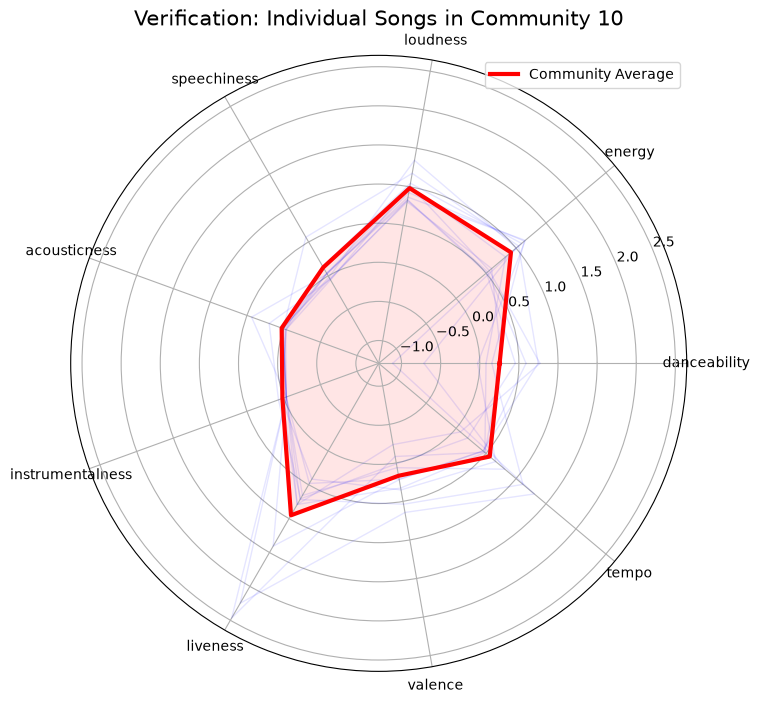

In [61]:
def plot_community_verification(comm_id, sample_size=10):
    categories = list(comm_scaled.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Get the community average
    avg_values = comm_scaled.iloc[comm_id].values.flatten().tolist()
    avg_values += avg_values[:1]
    
    # Get random songs from this community
    comm_songs = spotify[spotify['network_community'] == comm_id]
    sample_songs = comm_songs[continuous_features].sample(min(len(comm_songs), sample_size))
    # Scale sample songs using the same scaler used for the radar
    sample_scaled = scaler.transform(sample_songs)
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Plot individual songs (thin, transparent)
    for i in range(len(sample_scaled)):
        values = sample_scaled[i].tolist()
        values += values[:1]
        ax.plot(angles, values, color='blue', alpha=0.1, linewidth=1)
    
    # Plot the Average (bold, red)
    ax.plot(angles, avg_values, color='red', linewidth=3, label='Community Average')
    ax.fill(angles, avg_values, 'red', alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(f"Verification: Individual Songs in Community {comm_id}", size=15)
    plt.legend()
    plt.show()

# Run this for your "spikiest" community (e.g., Community 4 or 13)
plot_community_verification(10)

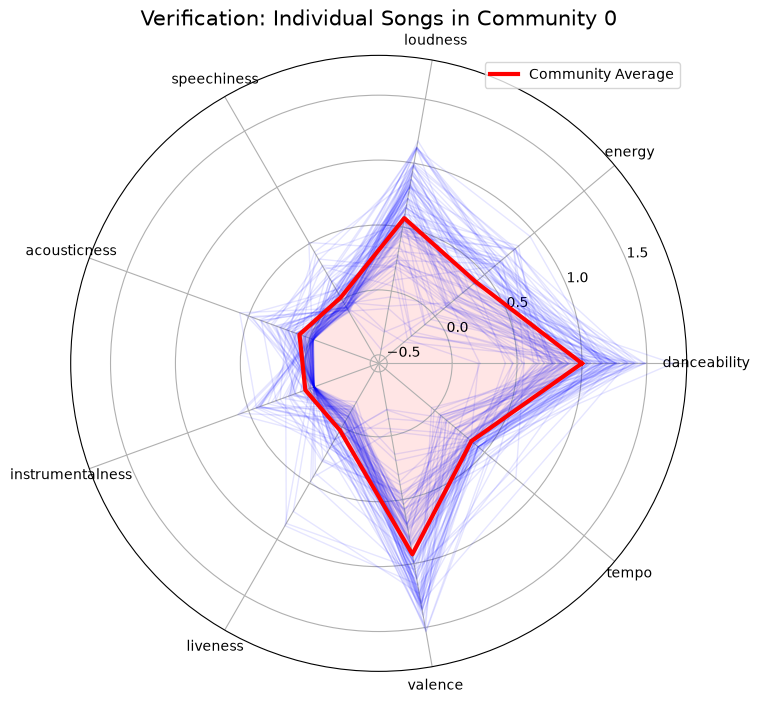

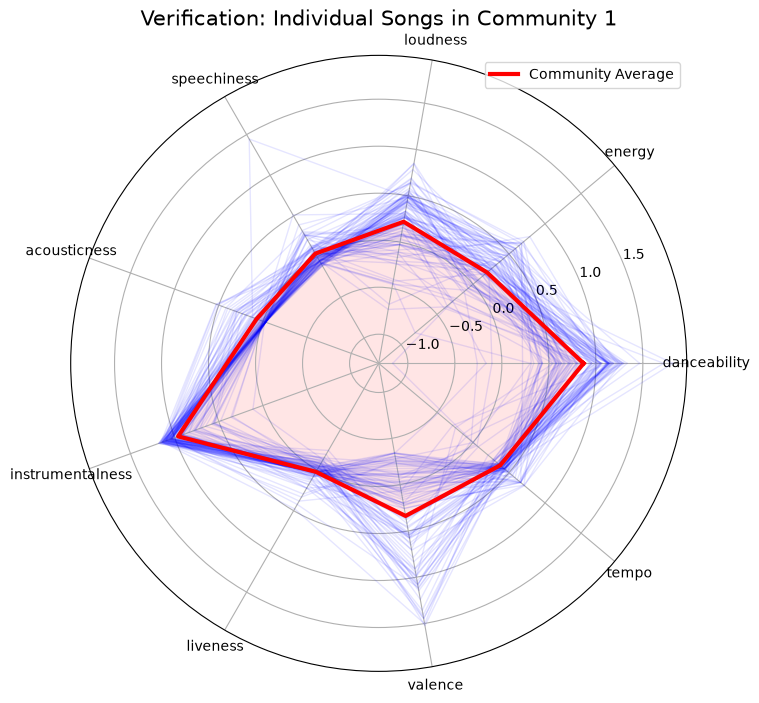

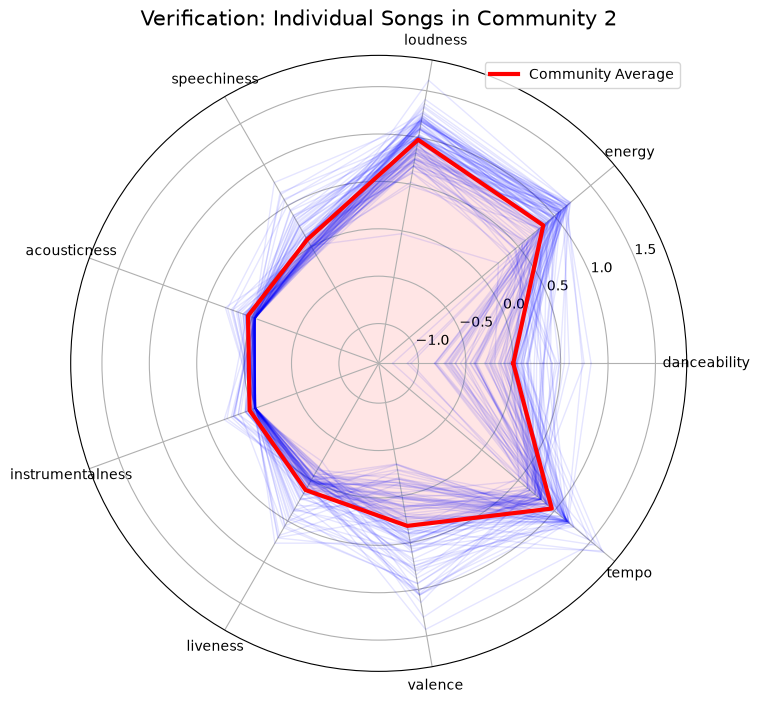

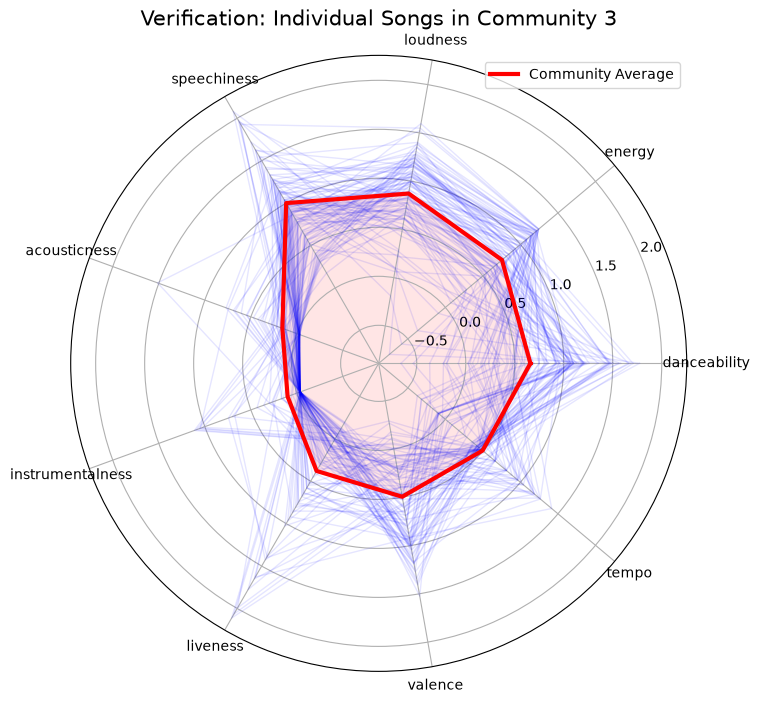

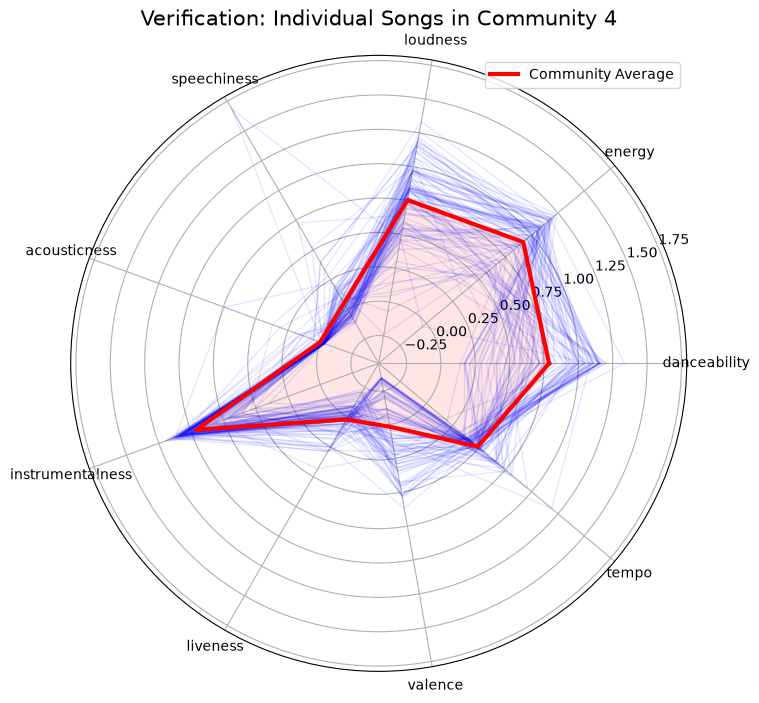

In [63]:
for i in range(5):
    plot_community_verification(i, 100)

In [ ]:
spotify

In [64]:
from scipy.spatial.distance import cosine

# Calculate distance of every song to its community centroid
def calculate_fidelity(row):
    comm_id = int(row['network_community'])
    centroid = comm_features.loc[comm_id].values
    song_vec = row[continuous_features].values
    # Fidelity is 1 - Cosine Distance
    return 1 - cosine(song_vec, centroid)

spotify['fidelity'] = spotify.apply(calculate_fidelity, axis=1)

# Average Fidelity per Community
fidelity_report = spotify.groupby('network_community')['fidelity'].mean()
print("Average Acoustic Fidelity per Community (Higher = More Consistent):")
print(fidelity_report.sort_values(ascending=False))

Average Acoustic Fidelity per Community (Higher = More Consistent):
network_community
8     0.833960
1     0.793785
4     0.790413
15    0.768170
7     0.768096
2     0.764149
12    0.762067
0     0.752259
11    0.739015
10    0.727889
13    0.719936
6     0.714412
14    0.711657
9     0.708182
5     0.685979
3     0.662460
Name: fidelity, dtype: float64


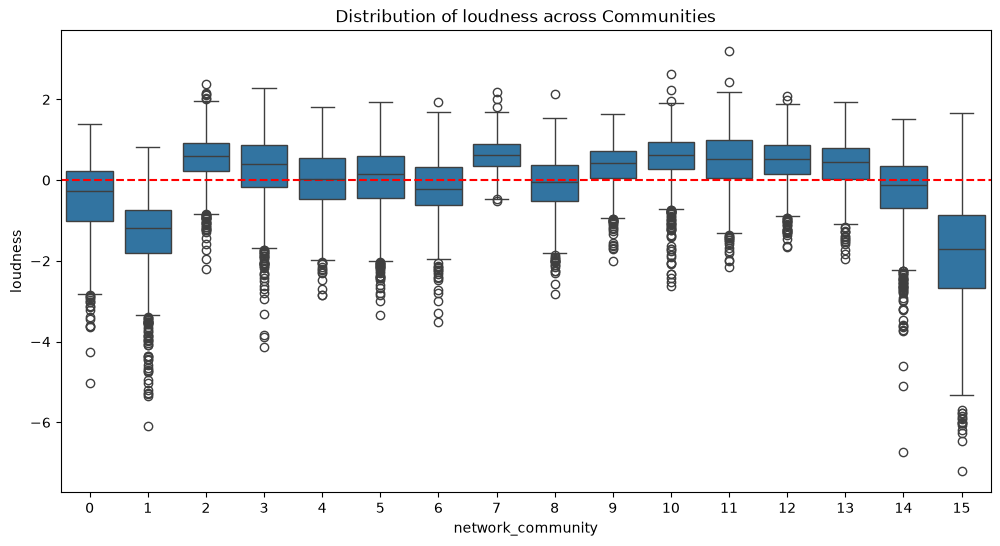

In [65]:
import seaborn as sns

# Pick a feature that has a spike in your radar (e.g., 'speechiness')
spike_feature = 'loudness' 

plt.figure(figsize=(12, 6))
sns.boxplot(x='network_community', y=spike_feature, data=spotify)
plt.title(f"Distribution of {spike_feature} across Communities")
plt.axhline(spotify[spike_feature].mean(), color='red', linestyle='--', label='Global Average')
plt.show()

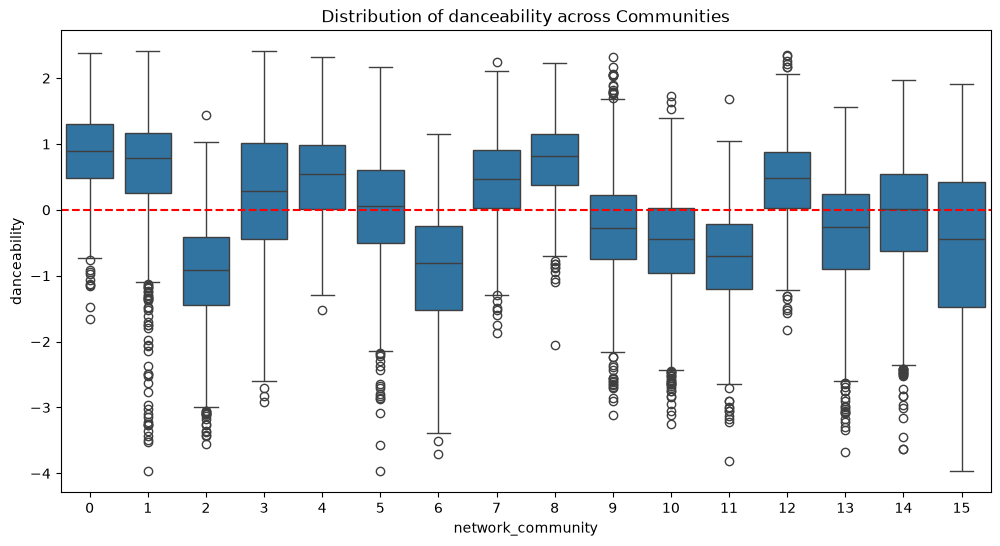

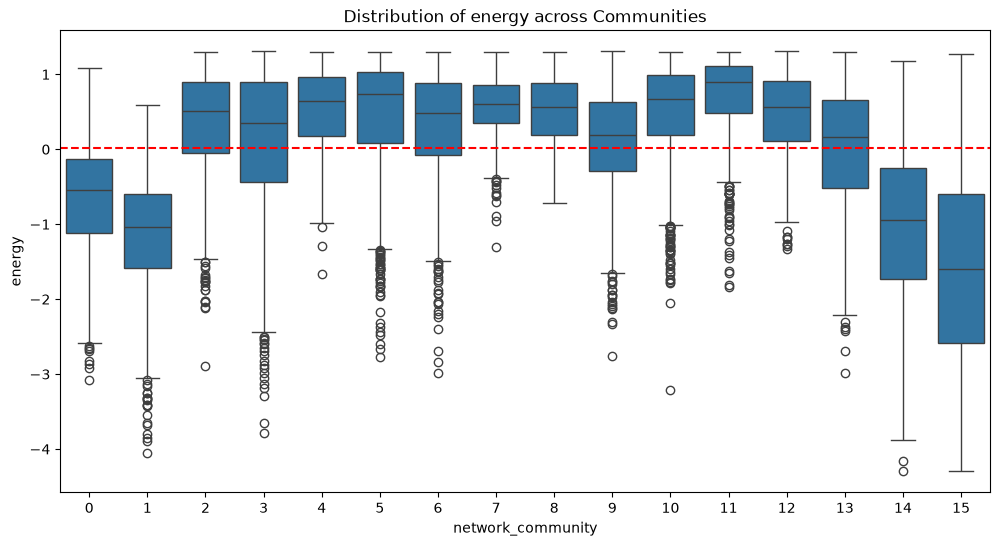

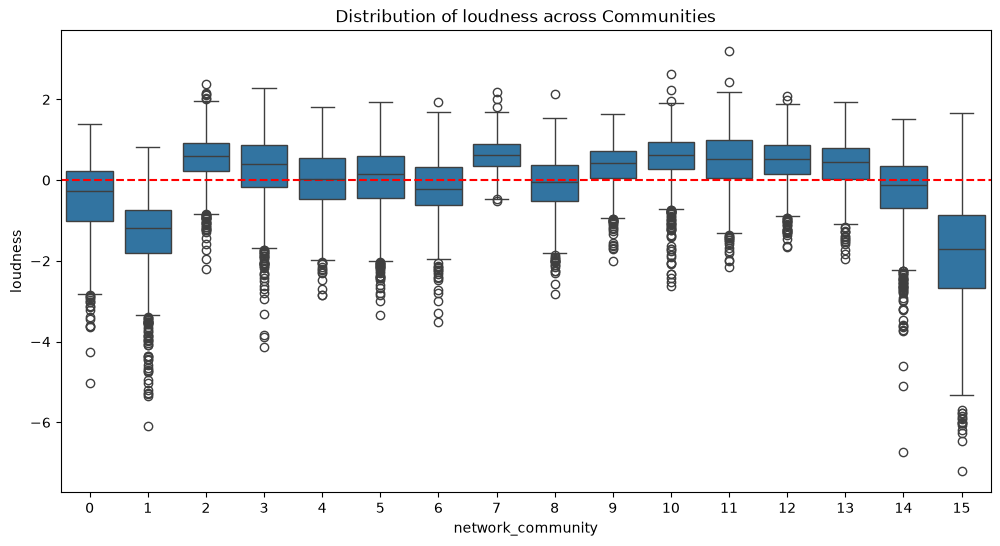

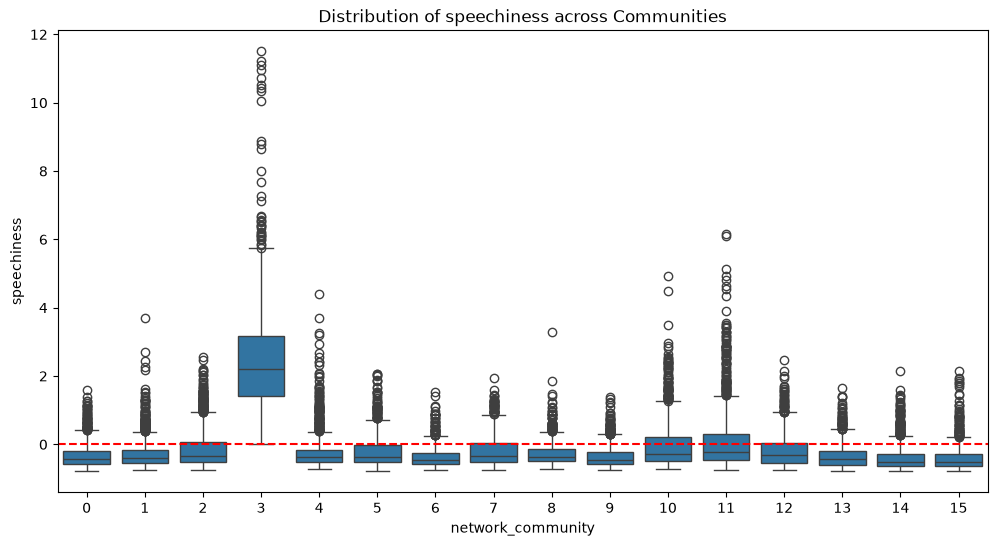

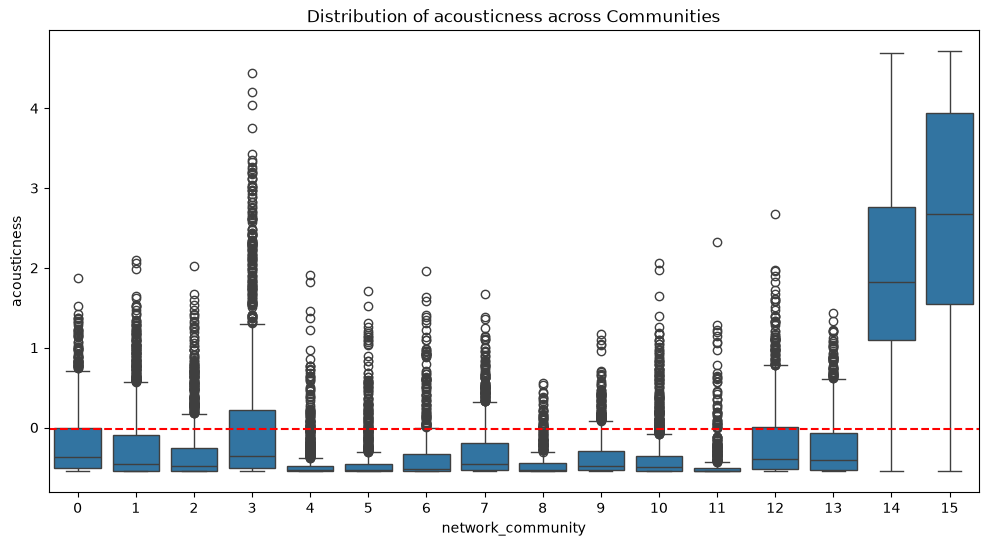

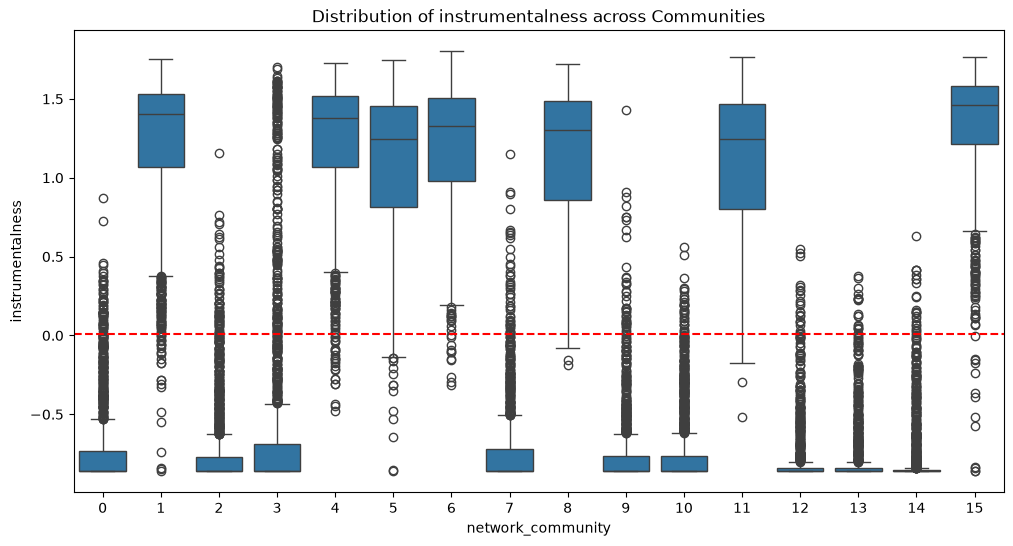

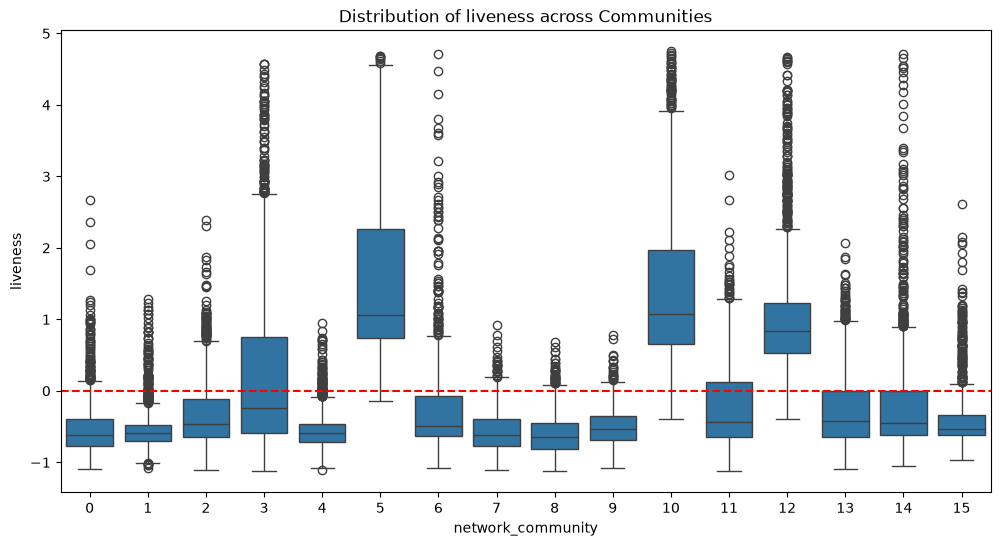

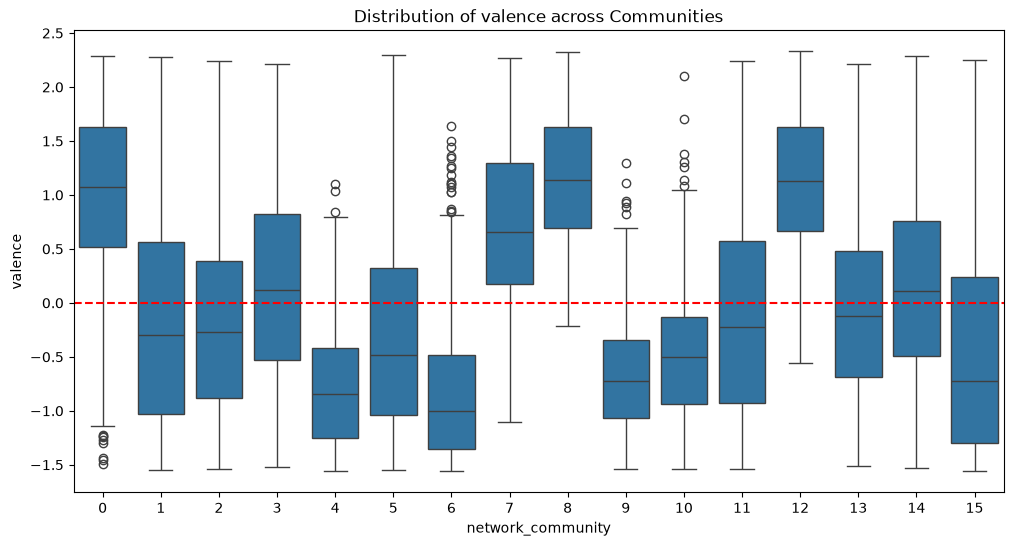

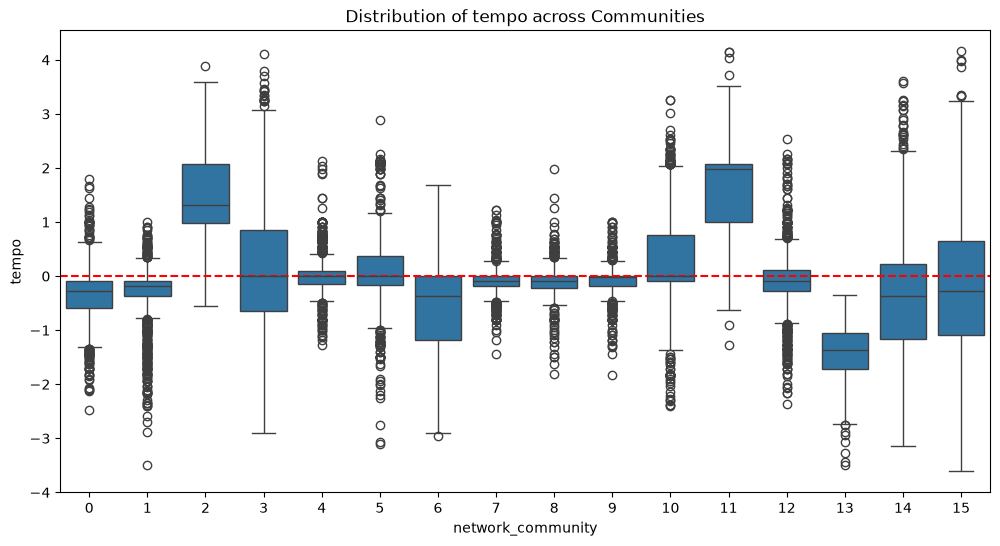

In [66]:
import seaborn as sns

# Pick a feature that has a spike in your radar (e.g., 'speechiness')

for feature in continuous_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='network_community', y=feature, data=spotify)
    plt.title(f"Distribution of {feature} across Communities")
    plt.axhline(spotify[feature].mean(), color='red', linestyle='--', label='Global Average')
    plt.show()

In [67]:
# 1. Calculate the Global Average for each feature
global_means = spotify[continuous_features].mean()

# 2. Calculate how much each community differs from the global average (Z-Score style)
# This highlights what makes each community 'special'
comm_diff = (comm_features - global_means) / spotify[continuous_features].std()

def get_identity(comm_id):
    # Find the feature with the highest positive deviation
    hero = comm_diff.loc[comm_id].idxmax()
    val = comm_diff.loc[comm_id].max()
    
    # Find the dominant macro-genre
    top_genre = spotify[spotify['network_community'] == comm_id]['genre'].mode()[0]
    genre_pct = (spotify[spotify['network_community'] == comm_id]['genre'] == top_genre).mean()
    
    return f"{hero} (+{val:.1f} std)", f"{top_genre} ({genre_pct:.1%})"

# Create a summary table for all 22
community_summary = pd.DataFrame(index=range(16))
community_summary[['Defining Feature', 'Primary Genre']] = [get_identity(i) for i in range(16)]
community_summary['Acoustic Fidelity'] = fidelity_report # From the previous step

print(community_summary.sort_values(by='Acoustic Fidelity', ascending=False))

               Defining Feature           Primary Genre  Acoustic Fidelity
8            valence (+1.2 std)             edm (24.5%)           0.833960
1   instrumentalness (+1.2 std)  minimal-techno (21.8%)           0.793785
4   instrumentalness (+1.2 std)             edm (31.2%)           0.790413
15      acousticness (+2.7 std)             idm (48.5%)           0.768170
7            valence (+0.7 std)             edm (40.3%)           0.768096
2              tempo (+1.4 std)       hardstyle (18.5%)           0.764149
12           valence (+1.1 std)             edm (31.7%)           0.762067
0            valence (+1.0 std)             edm (23.9%)           0.752259
11             tempo (+1.6 std)   drum-and-bass (37.3%)           0.739015
10          liveness (+1.4 std)             edm (41.1%)           0.727889
13          loudness (+0.4 std)             edm (23.2%)           0.719936
6   instrumentalness (+1.2 std)            club (17.1%)           0.714412
14      acousticness (+2.

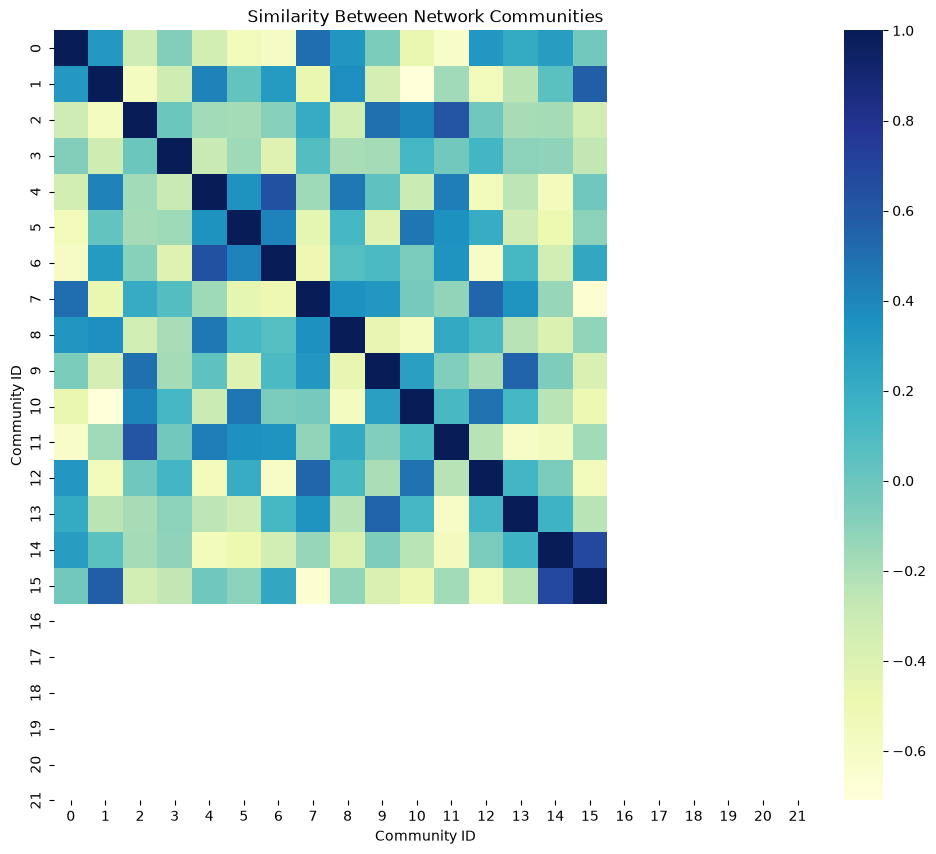

In [68]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute similarity between the 22 community centroids
comm_sim = cosine_similarity(comm_features)

plt.figure(figsize=(12, 10))
sns.heatmap(comm_sim, annot=False, cmap='YlGnBu', xticklabels=range(22), yticklabels=range(22))
plt.title("Similarity Between Network Communities")
plt.xlabel("Community ID")
plt.ylabel("Community ID")
plt.show()

In [71]:
archetype_list = []

for i in range(16):
    # Get the song with the highest fidelity in this community
    best_song = spotify[spotify['network_community'] == i].sort_values(by='fidelity', ascending=False).iloc[0]
    archetype_list.append({
        'Comm': i,
        'Track': best_song['name'],
        'Artist': best_song['artists'],
        'Genre': best_song['genre']
    })

archetype_df = pd.DataFrame(archetype_list)
print("The Archetype Gallery (One representative song for every community):")
print(archetype_df)

The Archetype Gallery (One representative song for every community):
    Comm                                              Track  \
0      0  Love's Got Me High - Marc Romboy's Systematic ...   
1      1                     Mistral - Stephan Bodzin Remix   
2      2                                      Got You There   
3      3                           Can U Dance (To My Beat)   
4      4                                 The Sound Of Space   
5      5                       Hypnotized - Joyhauser Remix   
6      6                                             Sodium   
7      7                                     In the Morning   
8      8                                            Eclipse   
9      9                       Fantasy - Nora En Pure Remix   
10    10                           High On You - Radio Edit   
11    11                     Solve Everything with Violence   
12    12                                  You Don't Know Me   
13    13                    Don't Speak (Glee Cas

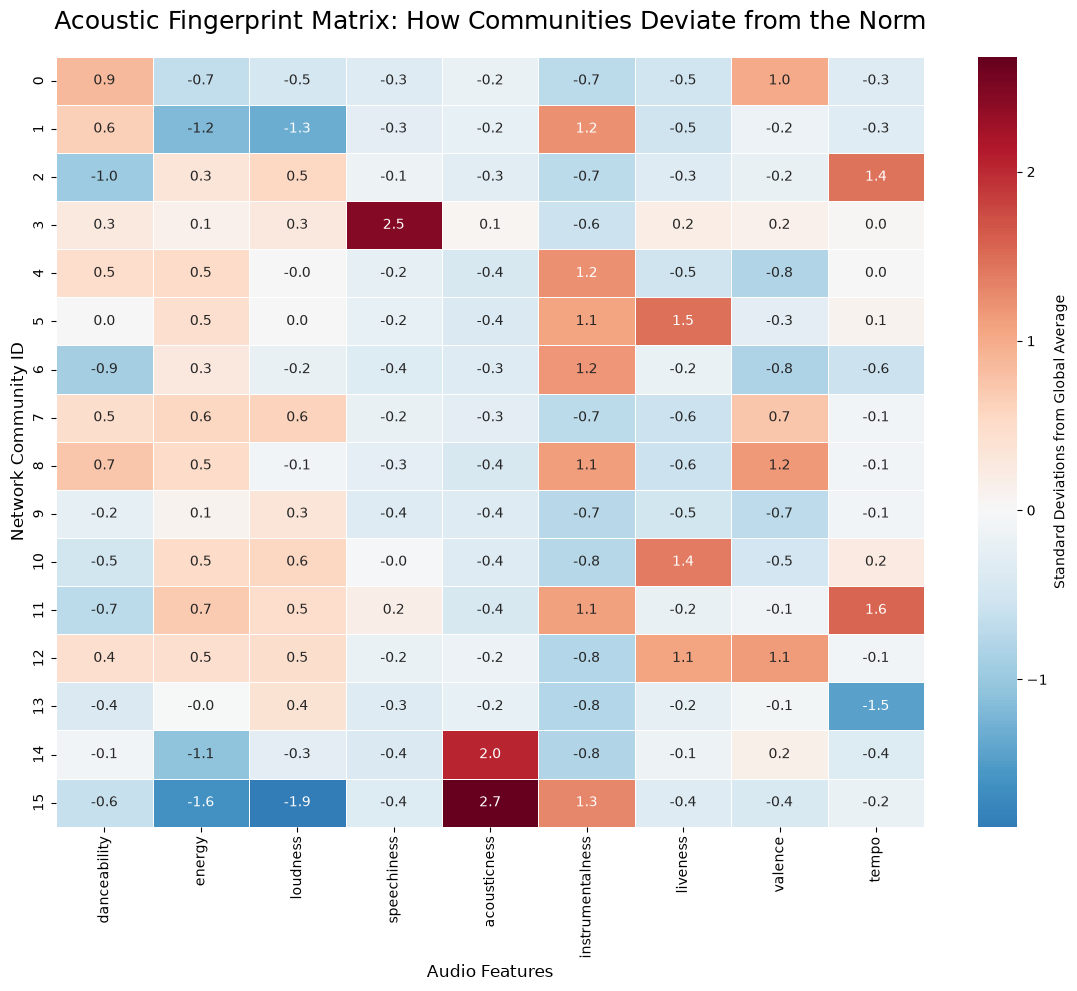

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Z-Scores (Standard Deviations from the Mean)
# This makes features like 'loudness' (-60 to 0) comparable to 'danceability' (0 to 1)
global_means = spotify[continuous_features].mean()
global_stds = spotify[continuous_features].std()
comm_z_scores = (comm_features - global_means) / global_stds

# 2. Plotting the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(comm_z_scores, 
            annot=True,      # Show the numbers
            fmt=".1f",       # 1 decimal place
            cmap="RdBu_r",   # Red for high, Blue for low, White for average
            center=0,        # Center the color bar at the global mean
            linewidths=.5, 
            cbar_kws={'label': 'Standard Deviations from Global Average'})

plt.title("Acoustic Fingerprint Matrix: How Communities Deviate from the Norm", fontsize=18, pad=20)
plt.xlabel("Audio Features", fontsize=12)
plt.ylabel("Network Community ID", fontsize=12)
plt.show()

C:\Users\pietr\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pietr\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pietr\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pietr\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figur

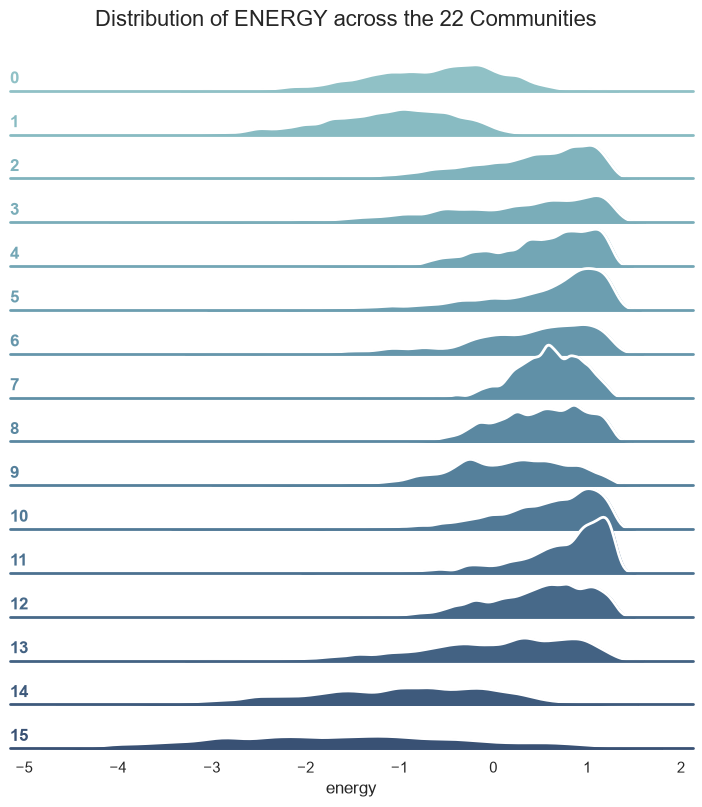

In [73]:
import seaborn as sns

def plot_ridge_joy(feature_name):
    # Set the aesthetic style
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(22, rot=-.25, light=.7)
    g = sns.FacetGrid(spotify, row="network_community", hue="network_community", 
                     aspect=15, height=.5, palette=pal)

    # Draw the densities
    g.map(sns.kdeplot, feature_name, bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, feature_name, clip_on=False, color="w", lw=2, bw_adjust=.5)

    # passing color=None to refline so it matches the hue
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)

    g.map(label, feature_name)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.25)

    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    plt.suptitle(f"Distribution of {feature_name.upper()} across the 22 Communities", fontsize=16)
    plt.show()

# Run for the most interesting feature
plot_ridge_joy('energy')

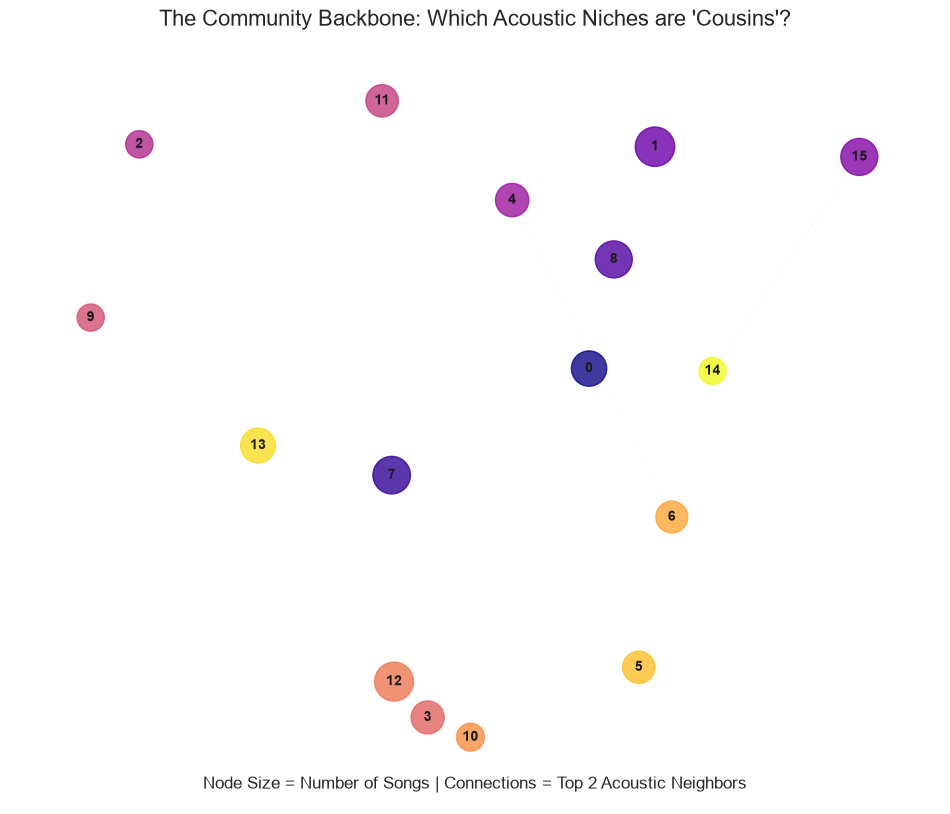

In [74]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute similarity between the 22 community centroids
comm_sim = cosine_similarity(comm_features)
sim_df = pd.DataFrame(comm_sim, index=range(16), columns=range(16))

# 2. Build the Meta-Graph
G_meta = nx.Graph()

# 3. Connect each community to its TOP 2 "Closest Cousins"
# This guarantees the graph won't be blank!
for i in range(16):
    # Get the most similar communities for community i (excluding itself)
    closest_cousins = sim_df.loc[i].sort_values(ascending=False)[1:3] 
    for neighbor, score in closest_cousins.items():
        G_meta.add_edge(i, neighbor, weight=score)

# 4. Visualization
plt.figure(figsize=(12, 10))

# Use Kamada-Kawai layout (better for seeing clusters of communities)
pos = nx.kamada_kawai_layout(G_meta)

# Node size based on how many songs are in that community
node_sizes = spotify['network_community'].value_counts().sort_index() * 0.5

# Node color based on the "Entropy" or "Fidelity" we calculated earlier
# (Or just a nice color map)
node_colors = range(16)

nx.draw_networkx_nodes(G_meta, pos, node_size=node_sizes, 
                       node_color=node_colors, cmap='plasma', alpha=0.8)

nx.draw_networkx_labels(G_meta, pos, font_size=10, font_weight='bold')

# Edge width based on how similar the communities are
edges = G_meta.edges(data=True)
weights = [d['weight']**10 * 5 for u, v, d in edges] # Emphasize strong links
nx.draw_networkx_edges(G_meta, pos, width=weights, edge_color='gray', alpha=0.3)

plt.title("The Community Backbone: Which Acoustic Niches are 'Cousins'?", fontsize=16)
plt.annotate("Node Size = Number of Songs | Connections = Top 2 Acoustic Neighbors", 
             xy=(0.5, 0.02), xycoords='axes fraction', ha='center')
plt.axis('off')
plt.show()

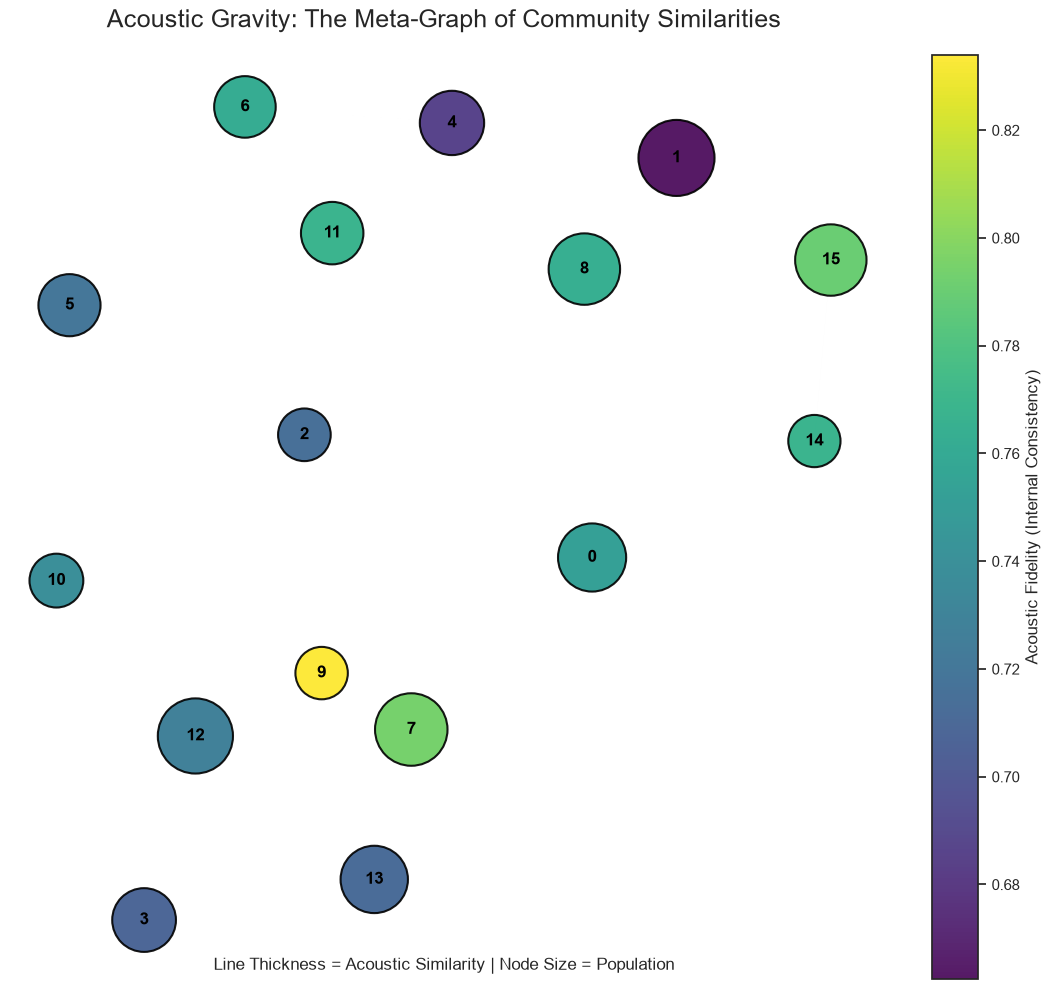

In [75]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 1. Similarity Matrix
comm_sim = cosine_similarity(comm_features)
sim_df = pd.DataFrame(comm_sim, index=range(16), columns=range(16))

# 2. Build Graph
G_weighted = nx.Graph()

# 3. Add Weighted Edges (Top 2 Neighbors)
for i in range(16):
    # Get top similarities (excluding self)
    top_neighbors = sim_df.loc[i].sort_values(ascending=False)[1:3]
    for neighbor, score in top_neighbors.items():
        # We store the raw score to use as 'weight'
        G_weighted.add_edge(i, neighbor, weight=score)

# 4. Visualization Setup
plt.figure(figsize=(14, 12))

# Layout: 'weight' parameter here tells the algorithm to pull similar nodes closer
pos = nx.spring_layout(G_weighted, weight='weight', k=0.7, iterations=100)

# Node Size: Relative to the number of songs in each community
node_counts = spotify['network_community'].value_counts().sort_index()
# Scaling node size for visibility
sizes = (node_counts / node_counts.max()) * 3000 

# Node Color: Let's use the 'Fidelity' to show which communities are most consistent
node_colors = fidelity_report.sort_index().values

# Edge Width & Alpha based on Strength
edges = G_weighted.edges(data=True)
# We amplify the difference in weights for visual impact (e.g., raise to power of 10)
edge_widths = [d['weight']**15 * 10 for u, v, d in edges]
edge_alphas = [d['weight']**5 for u, v, d in edges]

# 5. Drawing
# Draw Nodes
nodes = nx.draw_networkx_nodes(G_weighted, pos, 
                               node_size=sizes, 
                               node_color=node_colors, 
                               cmap='viridis', 
                               alpha=0.9, 
                               edgecolors='black', 
                               linewidths=1.5)

# Draw Labels
nx.draw_networkx_labels(G_weighted, pos, font_size=12, font_weight='bold', font_color='black')

# Draw Edges one by one to apply individual alphas
for (u, v, d), w, a in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(G_weighted, pos, 
                           edgelist=[(u, v)], 
                           width=w, 
                           alpha=a, 
                           edge_color='gray')

# Colorbar for Fidelity
cbar = plt.colorbar(nodes)
cbar.set_label('Acoustic Fidelity (Internal Consistency)', size=12)

plt.title("Acoustic Gravity: The Meta-Graph of Community Similarities", fontsize=18, pad=20)
plt.annotate("Line Thickness = Acoustic Similarity | Node Size = Population", 
             xy=(0.5, 0.01), xycoords='axes fraction', ha='center', fontsize=12)
plt.axis('off')
plt.show()

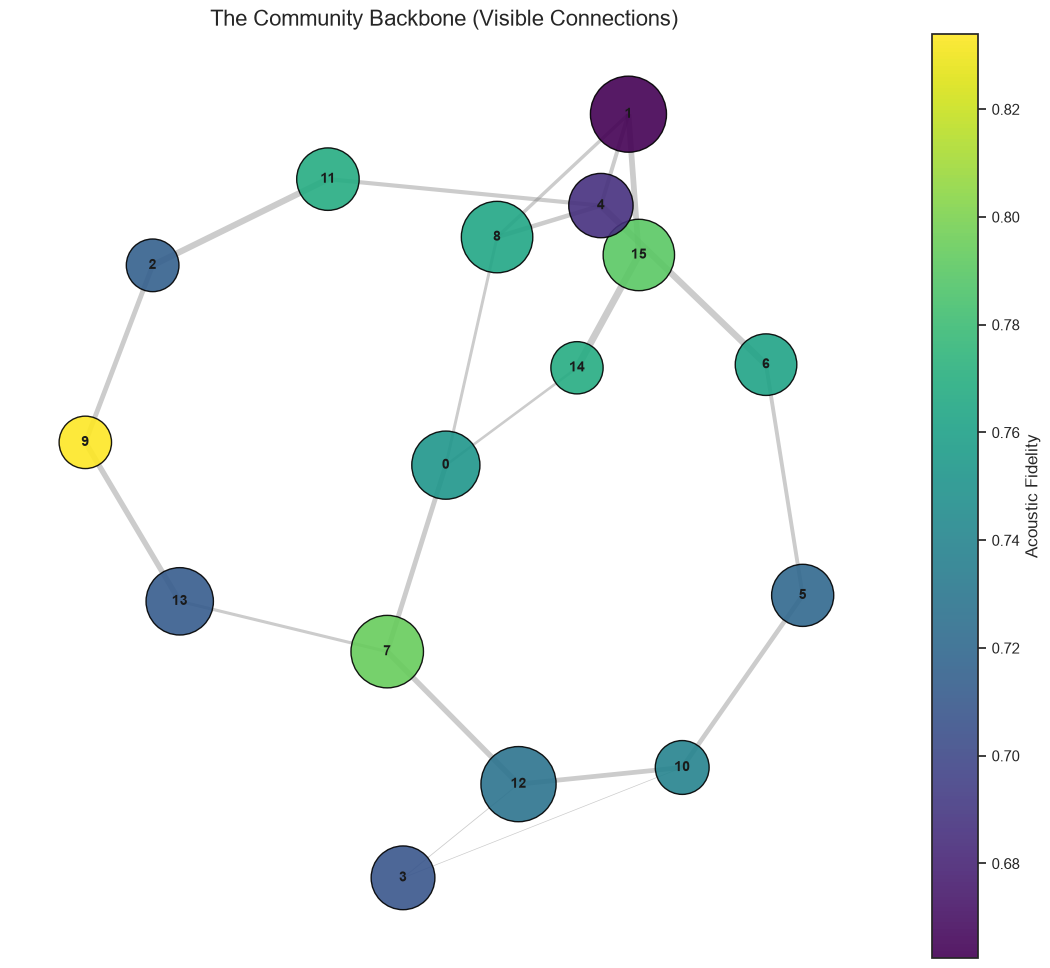

Min similarity between cousins: 0.1346
Max similarity between cousins: 0.6798


: 

In [ ]:
# --- REVISED DRAWING SECTION ---
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_weighted, weight='weight', k=0.5)

# Calculate widths using a gentler approach: (Similarity - Min Similarity)
# This ensures even weak connections are visible
raw_weights = [d['weight'] for u, v, d in G_weighted.edges(data=True)]
min_w, max_w = min(raw_weights), max(raw_weights)

# Scale weights so they range from 0.5 to 5.0 in thickness
def scale_weight(w):
    return 0.5 + 4.5 * ((w - min_w) / (max_w - min_w + 1e-9))

edge_widths = [scale_weight(d['weight']) for u, v, d in G_weighted.edges(data=True)]

# Draw Nodes
nodes = nx.draw_networkx_nodes(G_weighted, pos, 
                               node_size=sizes, 
                               node_color=node_colors, 
                               cmap='viridis', alpha=0.9, edgecolors='black')

# Draw Labels
nx.draw_networkx_labels(G_weighted, pos, font_size=10, font_weight='bold')

# Draw Edges with the new gentle scaling
nx.draw_networkx_edges(G_weighted, pos, width=edge_widths, edge_color='gray', alpha=0.4)

plt.colorbar(nodes, label='Acoustic Fidelity')
plt.title("The Community Backbone (Visible Connections)", fontsize=16)
plt.axis('off')
plt.show()

# Print the similarities to see why they were invisible
print(f"Min similarity between cousins: {min_w:.4f}")
print(f"Max similarity between cousins: {max_w:.4f}")